# 02 UQSD of Two Coherent States

There are two important properties to look at before continuing the experiments.

First, the overlap of canonical coherent states can be almost zero.
Since non-orthogonality is a basic assumption for unambiguous discrimination
of a set of quantum states, it is intuitive that we have to make sure the set
of quantum states does not contain states that are nearly identical or nearly
orthogonal. According to the formula of the overlap of canonical coherent
states, we immediately found that even though the overlap of two different
coherent states is always non-zero, it can be very close to zero. In other
words, the two distinct coherent states are in theory non-orthogonal, but they
are very close to orthogonal.

Second, the coherent states may have good approximations at
fairly low-dimensional Hilbert space. The canonical coherent states can be expanded with basis states as .... In practice, the formula is truncated to
enable simulation on classical computers. The fidelity of the truncated coherent state with respect to the canonical coherent state with the same alpha is ...
We will make sure the fidelity is at least 0.99, and will list it in our results.

To produce meaningful results, we check the two properties before running simulations.

Experiment description
We are going to discriminate a set of truncated coherent states.

We are going to explore different configurations. The experiments will be divided into two (or three)
sections:

The first task is to discriminate two coherent states, where their eigenvalues have the same magnitude but different phases. We will fix the magnitude and see the influence of changing phase on the resulting optimal POVMs. We will also explore the influence of different truncation (N).

The second task is to discriminate two coherent states, where their eigenvalues have different magnitudes but the same phase. We will fix the phase and see the influence of changing magnitude on the resulting optimal POVMs.

The third task will involve two states with different fixed magnitudes and observe the effects of increasing phase difference.

The fourth task extends the number of states, (3, 4), 

The fifth task invovles states with different overlaps
1. inner product (!)
2. radius on x-p diagram (uncertainty)

# Coherent states
This notebook will give a brief introduction of coherent states and show the results of different state discrimination setups. We will also go through some applications and theoretical results and discuss some properties that may affect the experimental results.

## Import required packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import coherent, coherent_dm
from qutip.visualization import plot_wigner
# from qutip.animation import anim_wigner

In [2]:
import sys

sys.path.append("..")

In [3]:
from utils.sparse import calculate_sparsity, evaluate_sparsity_for_dimensions

## Symmetric states

In [4]:
angles = [0, 2 * np.pi/3, 4 * np.pi/3]
symm_states = []

We want to explore unambiguous discrimination


In [5]:
alpha_arr = [np.exp((2 * i + 1) / 4 * np.pi * 1j) for i in range(4)]
coherent(N=32, alpha=alpha_arr[0] * 8)
coherent_dm(N=32, alpha=alpha_arr[0] * 8)

Quantum object: dims=[[32], [32]], shape=(32, 32), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 3.18980368e-06+0.00000000e+00j -9.11675513e-06+9.11675513e-06j
  -7.49465268e-19-3.57261375e-05j ...  7.78020319e-06-7.78020319e-06j
  -1.05892385e-19+5.28013083e-06j -5.25243396e-06-5.25243396e-06j]
 [-9.11675513e-06-9.11675513e-06j  5.21130655e-05+0.00000000e+00j
  -1.02108619e-04+1.02108619e-04j ... -4.44730864e-05-8.30092288e-19j
   1.50911042e-05-1.50911042e-05j -7.67411850e-19+3.00238880e-05j]
 [-7.49465268e-19+3.57261375e-05j -1.02108619e-04-1.02108619e-04j
   4.00136506e-04+0.00000000e+00j ...  8.71390959e-05+8.71390959e-05j
  -5.91380219e-05-2.42660719e-18j  5.88278140e-05-5.88278140e-05j]
 ...
 [ 7.78020319e-06+7.78020319e-06j -4.44730864e-05+8.30092288e-19j
   8.71390959e-05-8.71390959e-05j ...  3.79531581e-05+0.00000000e+00j
  -1.28786894e-05+1.28786894e-05j  1.76182853e-19-2.56222686e-05j]
 [-1.05892385e-19-5.28013083e-06j  1.50911042e-05+1.50911042e-05j
  -5.91380219e-0

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from qutip import wigner, isket, ket2dm
from math import sqrt


def plot_multiple_wigner(
    states,
    xvec=None,
    yvec=None,
    method="clenshaw",
    projection="2d",
    g=sqrt(2),
    sparse=False,
    parfor=False,
    colors=None,
    linestyles=None,
    colorbar=False,
    use_filled=False,
    save_path="wigner_plot.png",
    close_fig=False,
):
    """
    Plot Wigner functions for multiple quantum states on the same plot (contour lines)
    or in a grid (filled contours) and save as a .png.

    Parameters
    ----------
    states : list of :obj:`.Qobj`
        List of density matrices or kets to visualize.
    xvec : array_like, optional
        x-coordinates for Wigner function.
    yvec : array_like, optional
        y-coordinates for Wigner function.
    method : str {'clenshaw', 'iterative', 'laguerre', 'fft'}, default: 'clenshaw'
        Method for calculating the Wigner function.
    projection : str {'2d', '3d'}, default: '2d'
        Plot as contour ('2d') or surface ('3d').
    g : float
        Scaling factor, default `g = sqrt(2)`.
    sparse : bool
        Use sparse format.
    parfor : bool
        Use parallel calculation.
    colors : list of colors, optional
        Colors for each state’s contours (e.g., ['blue', 'red', 'green']).
        If None, uses ['b', 'r', 'g', 'k', ...].
    linestyles : list of linestyles, optional
        Linestyles for contours (e.g., ['-', '--', ':']).
        If None, all use '-'.
    colorbar : bool
        Whether to include a colorbar (only for filled contours).
    use_filled : bool
        If True, plot filled contours in a grid of subplots instead of overlapping contours.
    save_path : str
        Path to save the .png file, default 'wigner_plot.png'.
    close_fig : bool
        Whether to close the figure after saving, default False.

    Returns
    -------
    fig, ax : tuple
        Matplotlib figure and axes (or list of axes for grid) used for the plot.
    """
    # Default coordinates
    xvec = np.linspace(-7.5, 7.5, 200) if xvec is None else xvec
    yvec = np.linspace(-7.5, 7.5, 200) if yvec is None else yvec
    wlim = 0
    Ws = []

    # Compute Wigner functions
    for state in states:
        if isket(state):
            state = ket2dm(state)
        W = wigner(
            state, xvec, yvec, method=method, g=g, sparse=sparse, parfor=parfor
        )
        Ws.append(W)
        wlim = max(abs(W).max(), wlim)

    # Set normalization
    norm = mpl.colors.Normalize(-wlim, wlim)

    # Default colors and linestyles
    if colors is None:
        colors = ["b", "r", "g", "k", "c", "m", "y"][: len(states)]
    if linestyles is None:
        linestyles = ["-"] * len(states)
    else:
        linestyles = linestyles[: len(states)]

    if use_filled:
        # Grid layout for filled contours
        n_states = len(states)
        ncols = int(np.ceil(np.sqrt(n_states)))
        nrows = int(np.ceil(n_states / ncols))
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(4 * ncols, 4 * nrows),
            sharex=True,
            sharey=True,
        )
        axes = np.atleast_2d(axes).ravel() if n_states > 1 else [axes]

        for i, (W, ax) in enumerate(zip(Ws, axes[:n_states])):
            if projection == "2d":
                cf = ax.contourf(xvec, yvec, W, 100, norm=norm, cmap="RdBu")
                ax.contour(xvec, yvec, W, 10, colors="black", linewidths=0.5)
                ax.set_title(rf"$N = {2 ** (i+1)}$")
                if colorbar:
                    plt.colorbar(cf, ax=ax)
            else:
                X, Y = np.meshgrid(xvec, yvec)
                ax.plot_surface(X, Y, W, rstride=5, cstride=5, cmap="RdBu")
            ax.set_xlabel(r"$\rm{Re}(\alpha)$")
            ax.set_ylabel(r"$\rm{Im}(\alpha)$")

        # Hide unused subplots
        for ax in axes[n_states:]:
            ax.set_visible(False)

        fig.tight_layout()
    else:
        # Single plot with contour lines
        fig, ax = plt.subplots(figsize=(6, 6))
        for i, (W, color, linestyle) in enumerate(zip(Ws, colors, linestyles)):
            if projection == "2d":
                ax.contour(
                    xvec,
                    yvec,
                    W,
                    10,
                    colors=color,
                    linestyles=linestyle,
                    linewidths=1.5,
                    label=rf"$N = {2 ** (i+1)}$",
                )
            else:
                X, Y = np.meshgrid(xvec, yvec)
                ax.plot_wireframe(
                    X,
                    Y,
                    W,
                    color=color,
                    linestyle=linestyle,
                    rstride=5,
                    cstride=5,
                )
        ax.set_xlabel(r"$\rm{Re}(\alpha)$", fontsize=12)
        ax.set_ylabel(r"$\rm{Im}(\alpha)$", fontsize=12)
        ax.legend()
        ax.set_title("Wigner Functions of Coherent States", fontsize=14)

    # Save the plot
    plt.suptitle(
        r"Wigner Function of Truncated Coherent States $|\alpha| = 4, \angle{\alpha}=\pi/4$",
        y=0,
        fontsize=14,
    )
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # Close figure only if requested
    if close_fig:
        plt.close(fig)

    return fig, ax

/tmp/ipykernel_1414989/3463169871.py:130: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
/tmp/ipykernel_1414989/3463169871.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


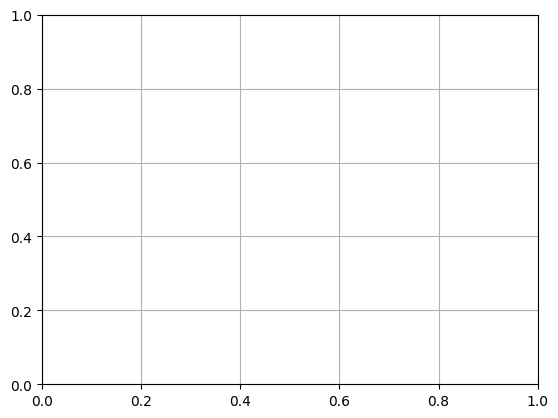

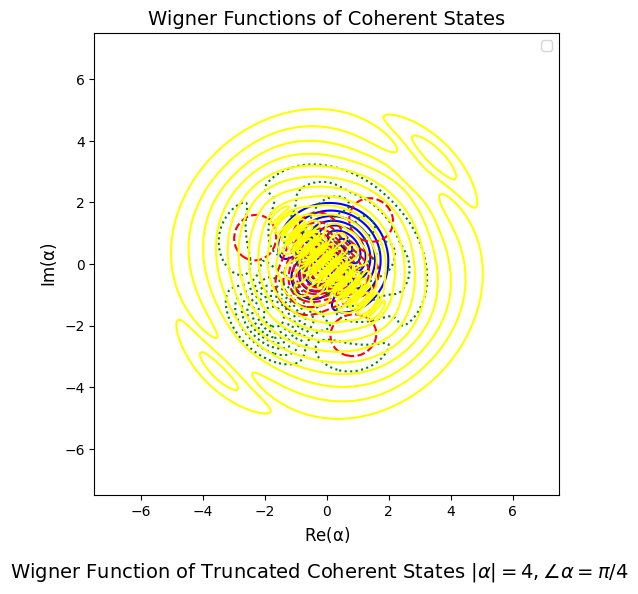

In [7]:
# The two set of states look completely different...
states = [coherent_dm(N=32, alpha=alpha_arr[i] * 4) for i in range(4)]
states = [coherent_dm(N=2 ** (1 + i), alpha=alpha_arr[0] * 4) for i in range(9)]
# states = [coherent_dm(N=64, alpha=alpha_arr[i] * 4) for i in range(4)]
# states = [coherent_dm(N=128, alpha=alpha_arr[i] * 4) for i in range(4)]
# fig, ani = plot_wigner(
#     states,
#     projection='2d',
# )
plt.grid(True)
# ani.save("test.gif")
# fig.savefig("test.png")
fig, ax = plot_multiple_wigner(
    states,
    projection="2d",
    colors=["blue", "red", "green", "yellow"],
    linestyles=["-", "--", ":", "-"],
    colorbar=True,
    use_filled=False,
    save_path="coherent_states_wigner_contours.png",
    close_fig=False,
)

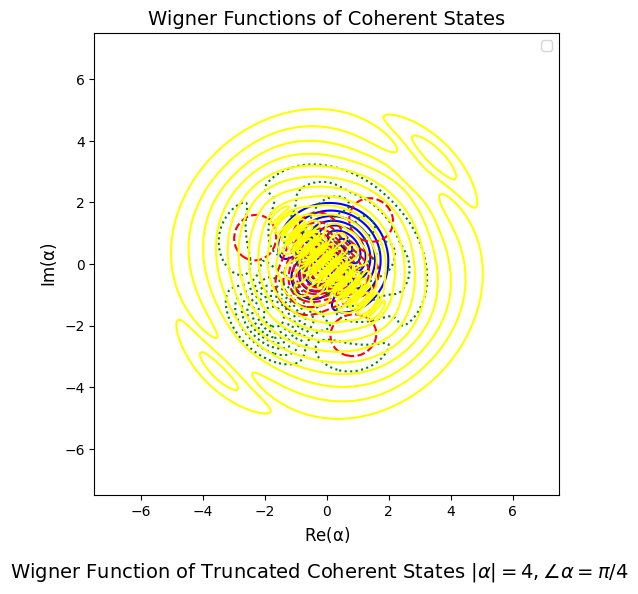

In [8]:
fig.suptitle(
    r"Wigner Function of Truncated Coherent States $|\alpha| = 4, \angle{\alpha}=\pi/4$",
    y=0,
    fontsize=14,
)
fig

We can view the density matrices by drawing its real part and imaginary part or drawing the absolute value of its elements. While it may not be the best way, and it is not as fast as directly printing the matrices, it should provide some intuition.

In [9]:
coh_n32_arr = [coherent_dm(N=32, alpha=alpha * 8) for alpha in alpha_arr]

In [10]:
import sys

sys.path.append("..")
from utils.complex_heatmap import ComplexHeatmap
c_heatmap = ComplexHeatmap()

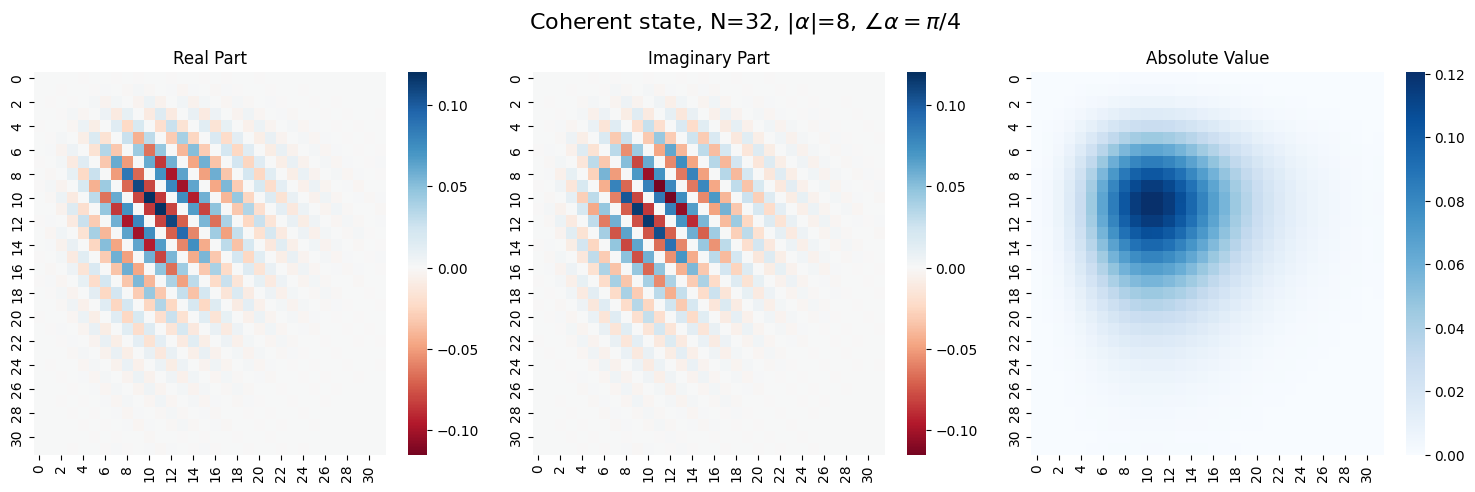

In [11]:
c_heatmap.plot(
    coh_n32_arr[0].data.to_array(),
    annot=False,
    title=r"Coherent state, N=32, $|\alpha|$=8, $\angle{\alpha}=\pi/4$",
    show_phase=False,
)

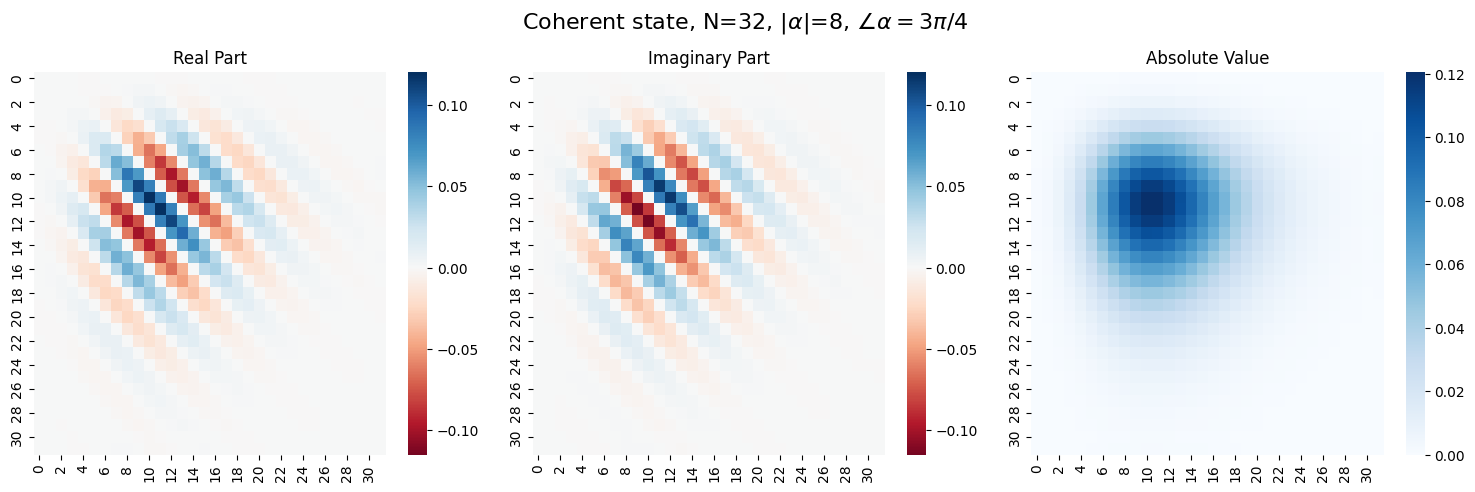

In [12]:
c_heatmap.plot(
    coh_n32_arr[1].data.to_array(),
    annot=False,
    title=r"Coherent state, N=32, $|\alpha|$=8, $\angle{\alpha}=3\pi/4$",
    show_phase=False,
)

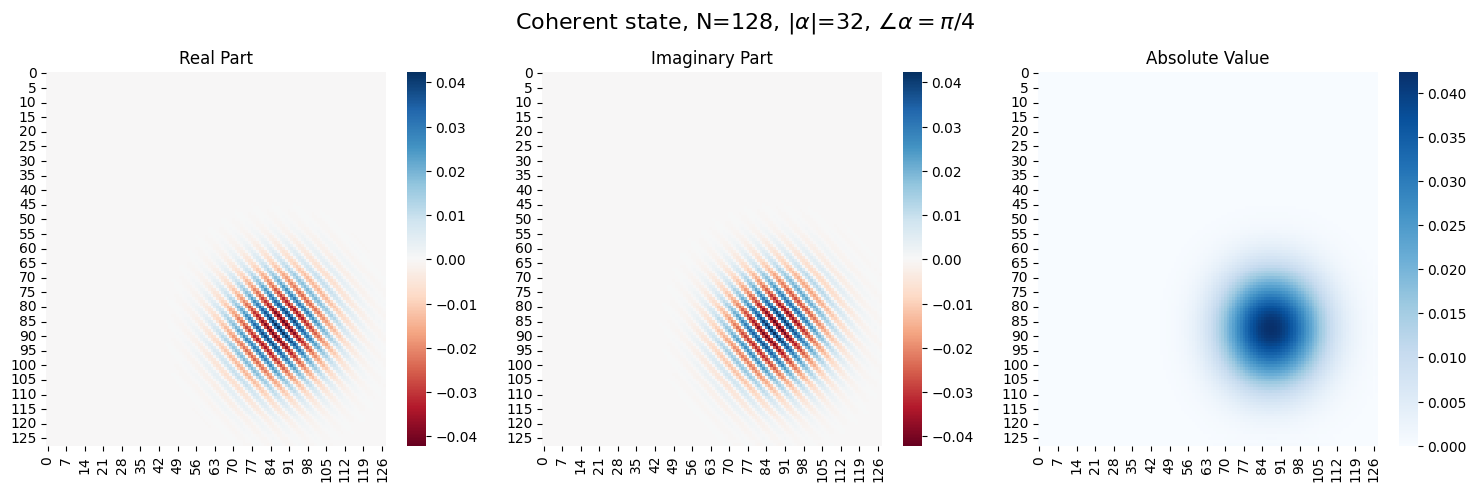

In [13]:
c_heatmap.plot(
    coherent_dm(N=128, alpha=alpha_arr[0] * 32).data.to_array(),
    annot=False,
    title=r"Coherent state, N=128, $|\alpha|$=32, $\angle{\alpha}=\pi/4$",
    show_phase=False,
)

## Sparsity of coherent state density matrices
From the previous examples, we can see that the density matrices of coherent states can be very sparse. How sparse are these density matrices? Maybe we can take advantage of this sparsity and improve our results.

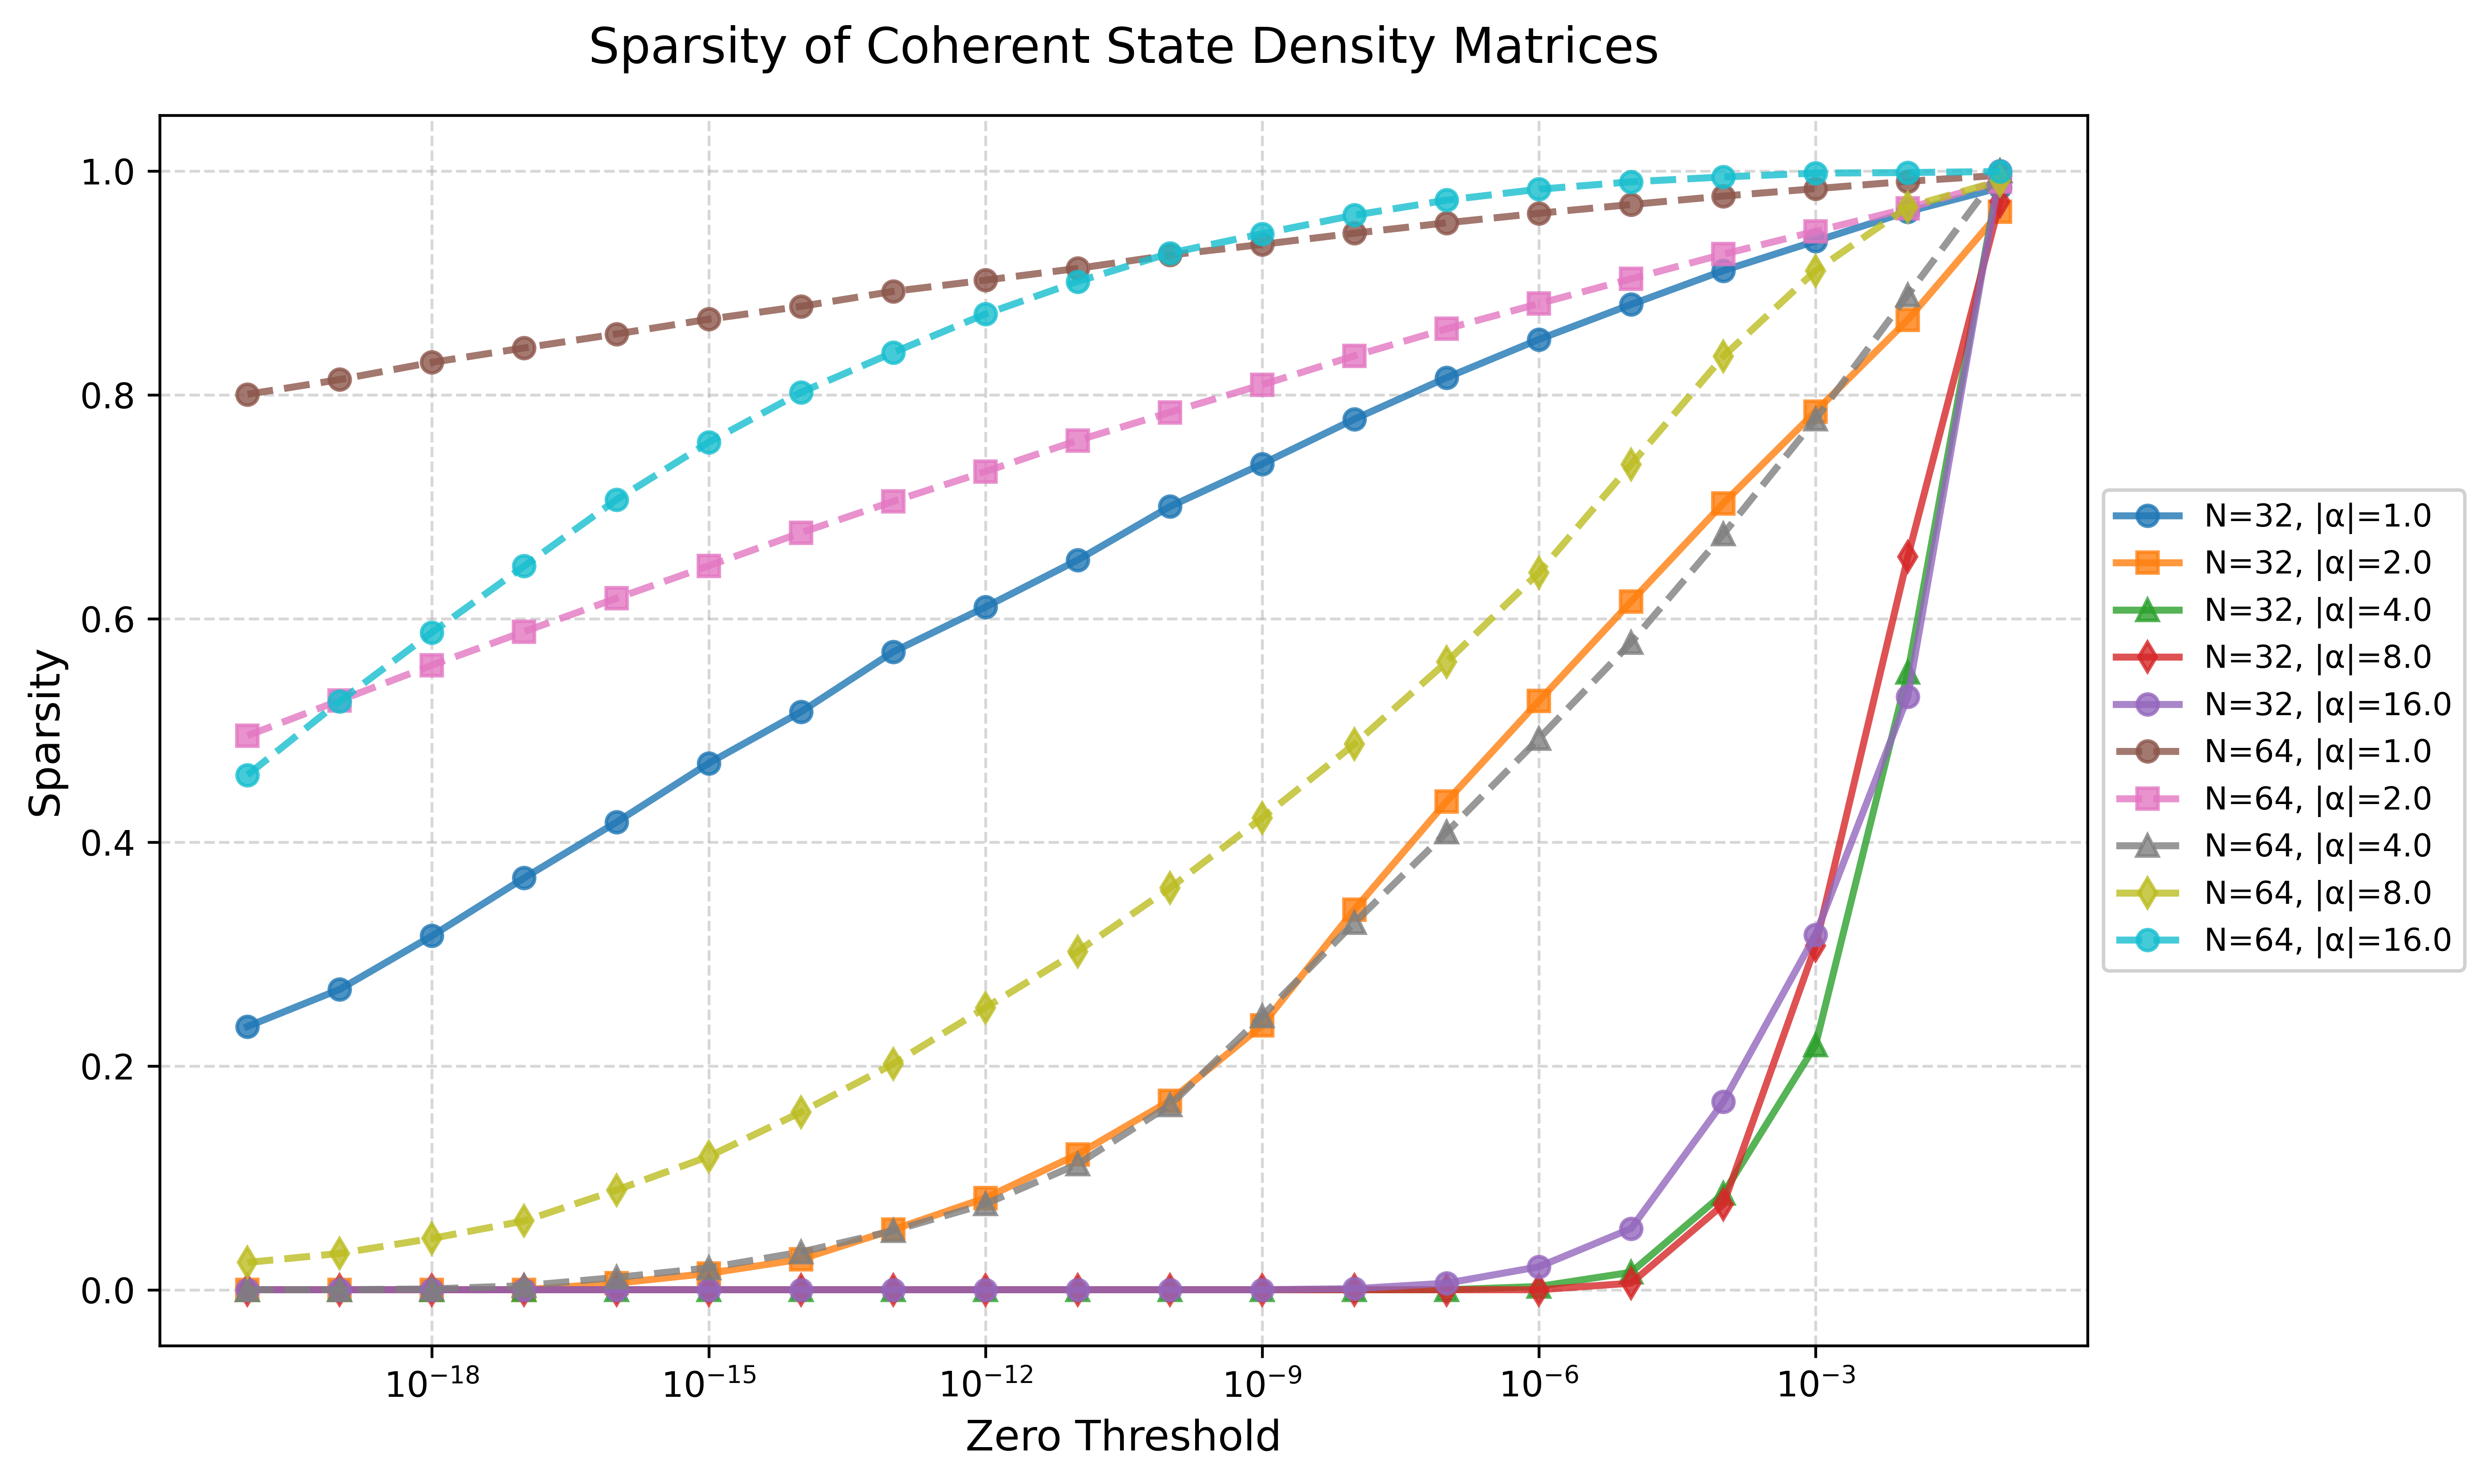

In [14]:
# Collaborated with Grok 3

import numpy as np
from qutip import coherent_dm
import matplotlib.pyplot as plt
import pandas as pd
from utils.sparse import evaluate_sparsity_for_dimensions


# Parameters
N_values = [32, 64]
alpha_scales = [1, 2, 4, 8, 16]
thresholds = np.logspace(-20, -1, 20)
alpha_base = alpha_arr[0]  # Assumed defined

# Run and convert to DataFrame
results = evaluate_sparsity_for_dimensions(
    N_values, alpha_scales, thresholds, alpha_base
)
df = pd.DataFrame(results)

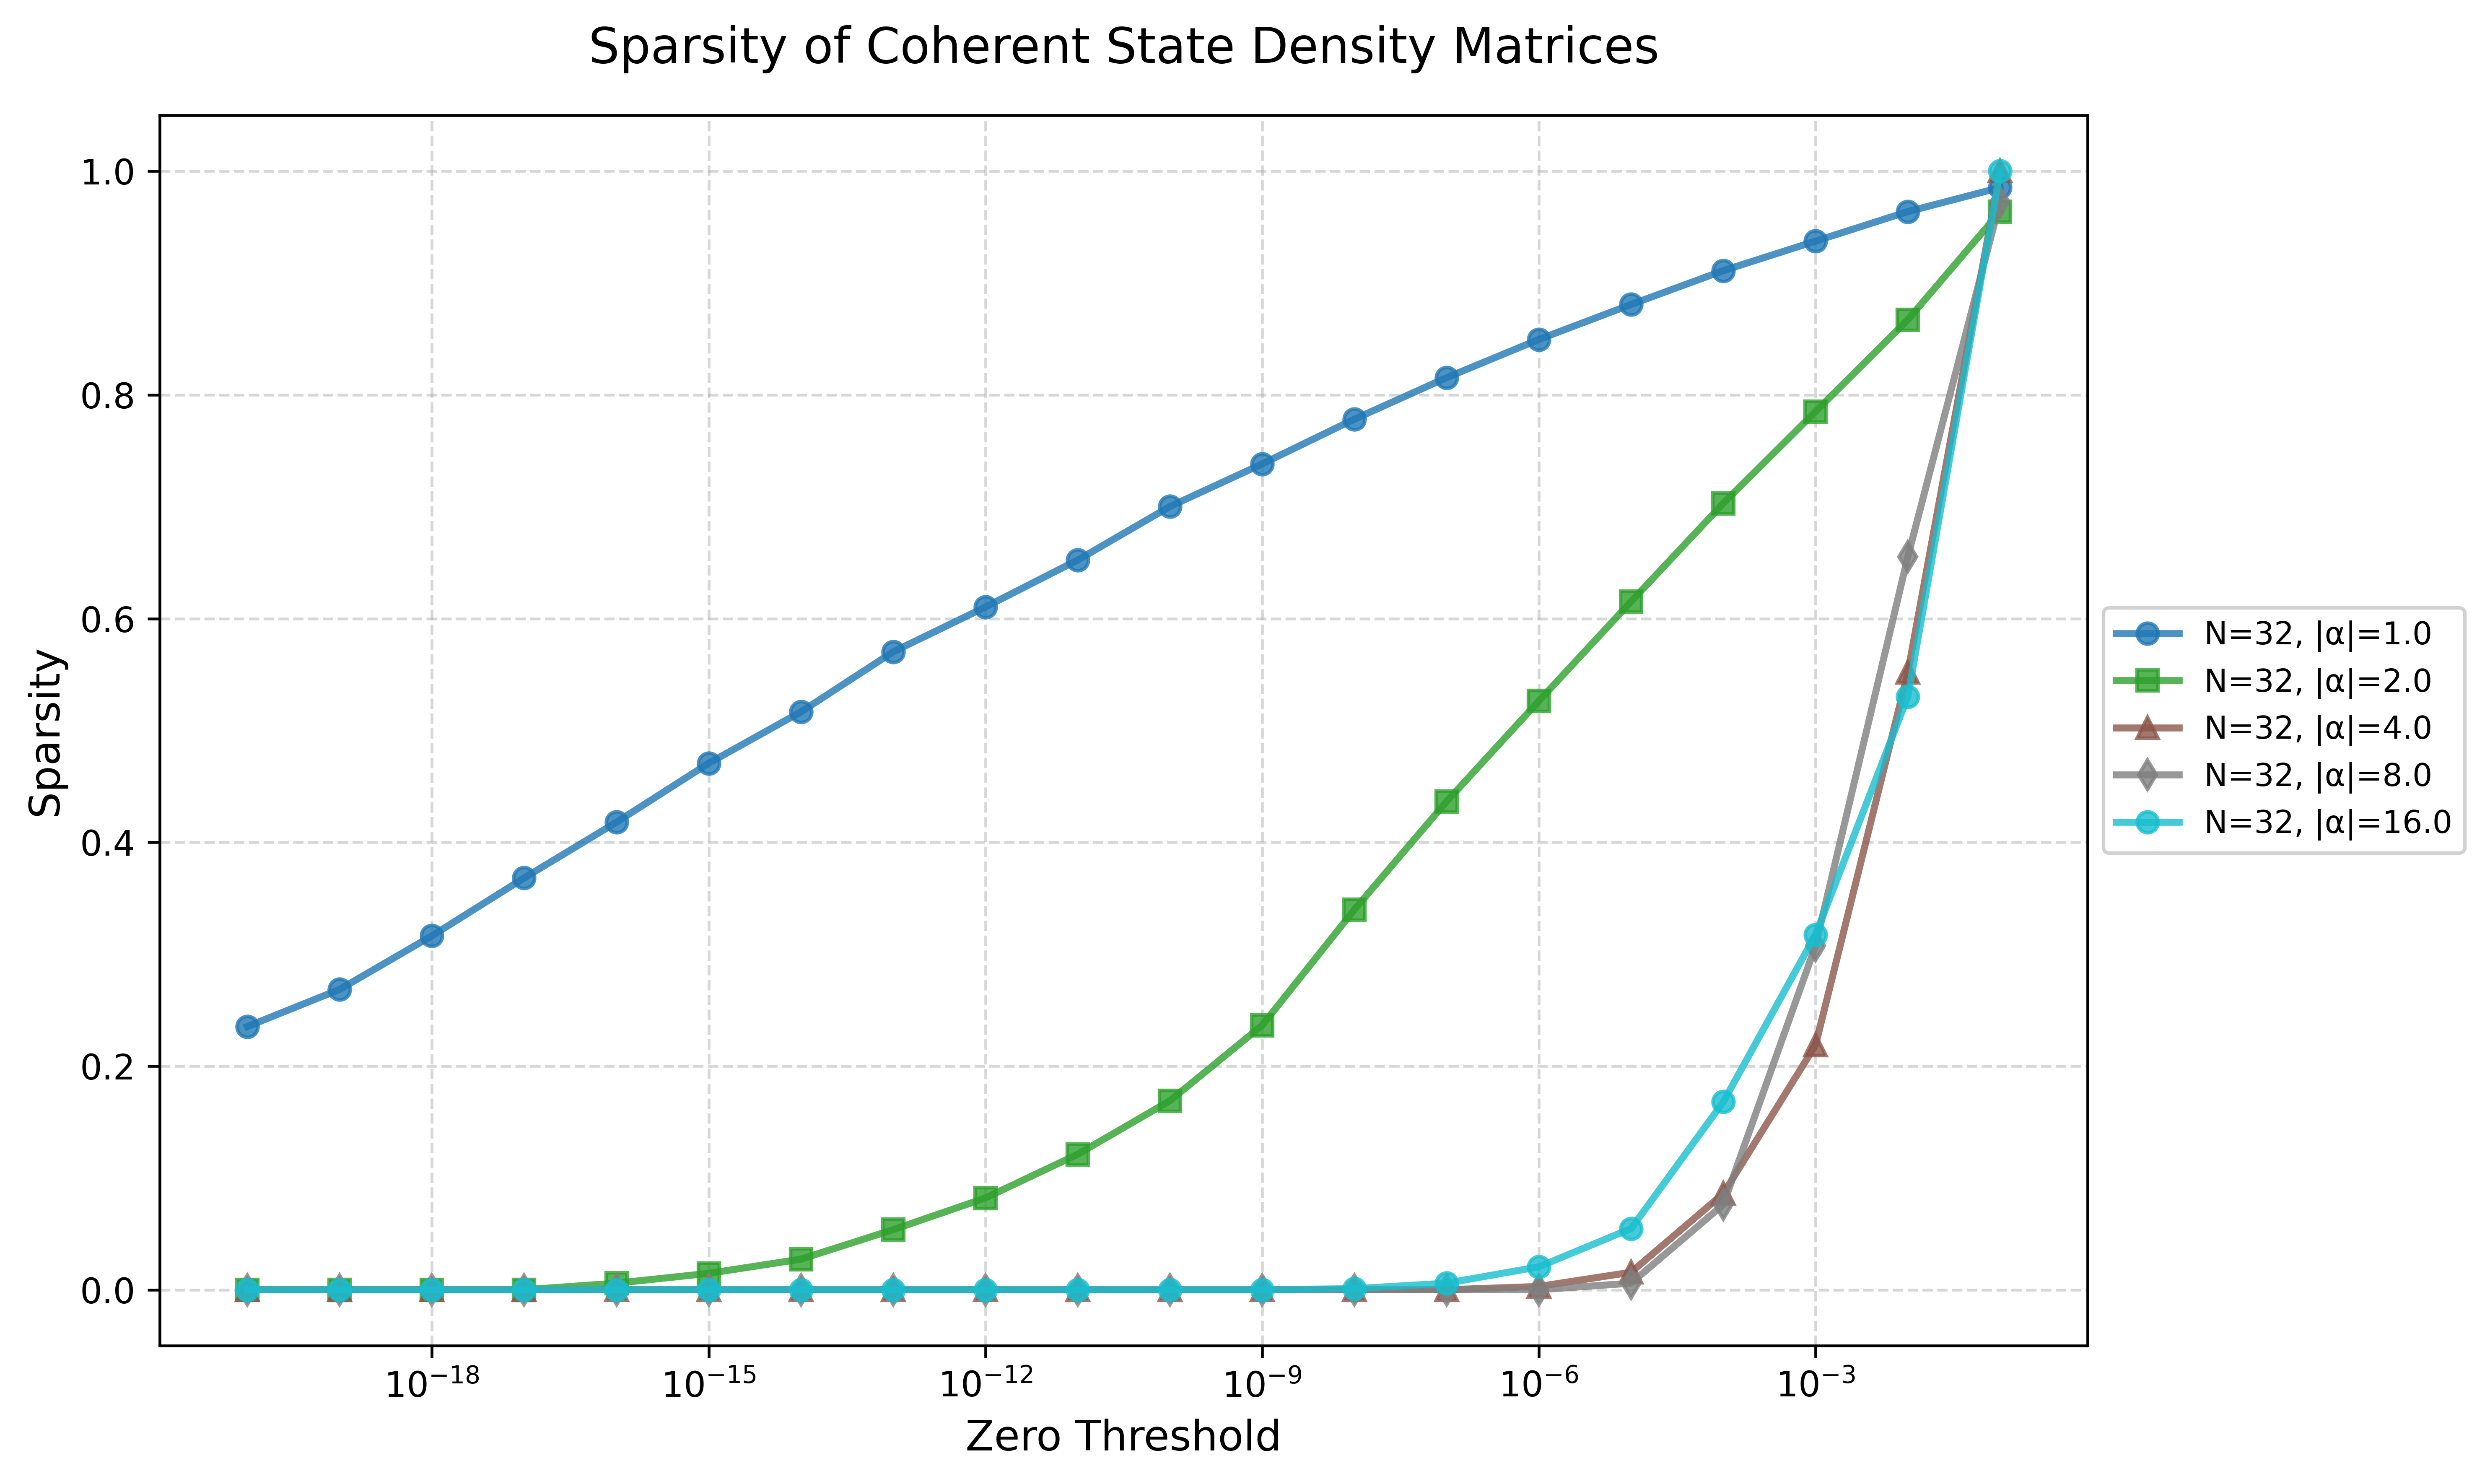

In [15]:
results = evaluate_sparsity_for_dimensions(
    [32], alpha_scales, thresholds, alpha_base
)

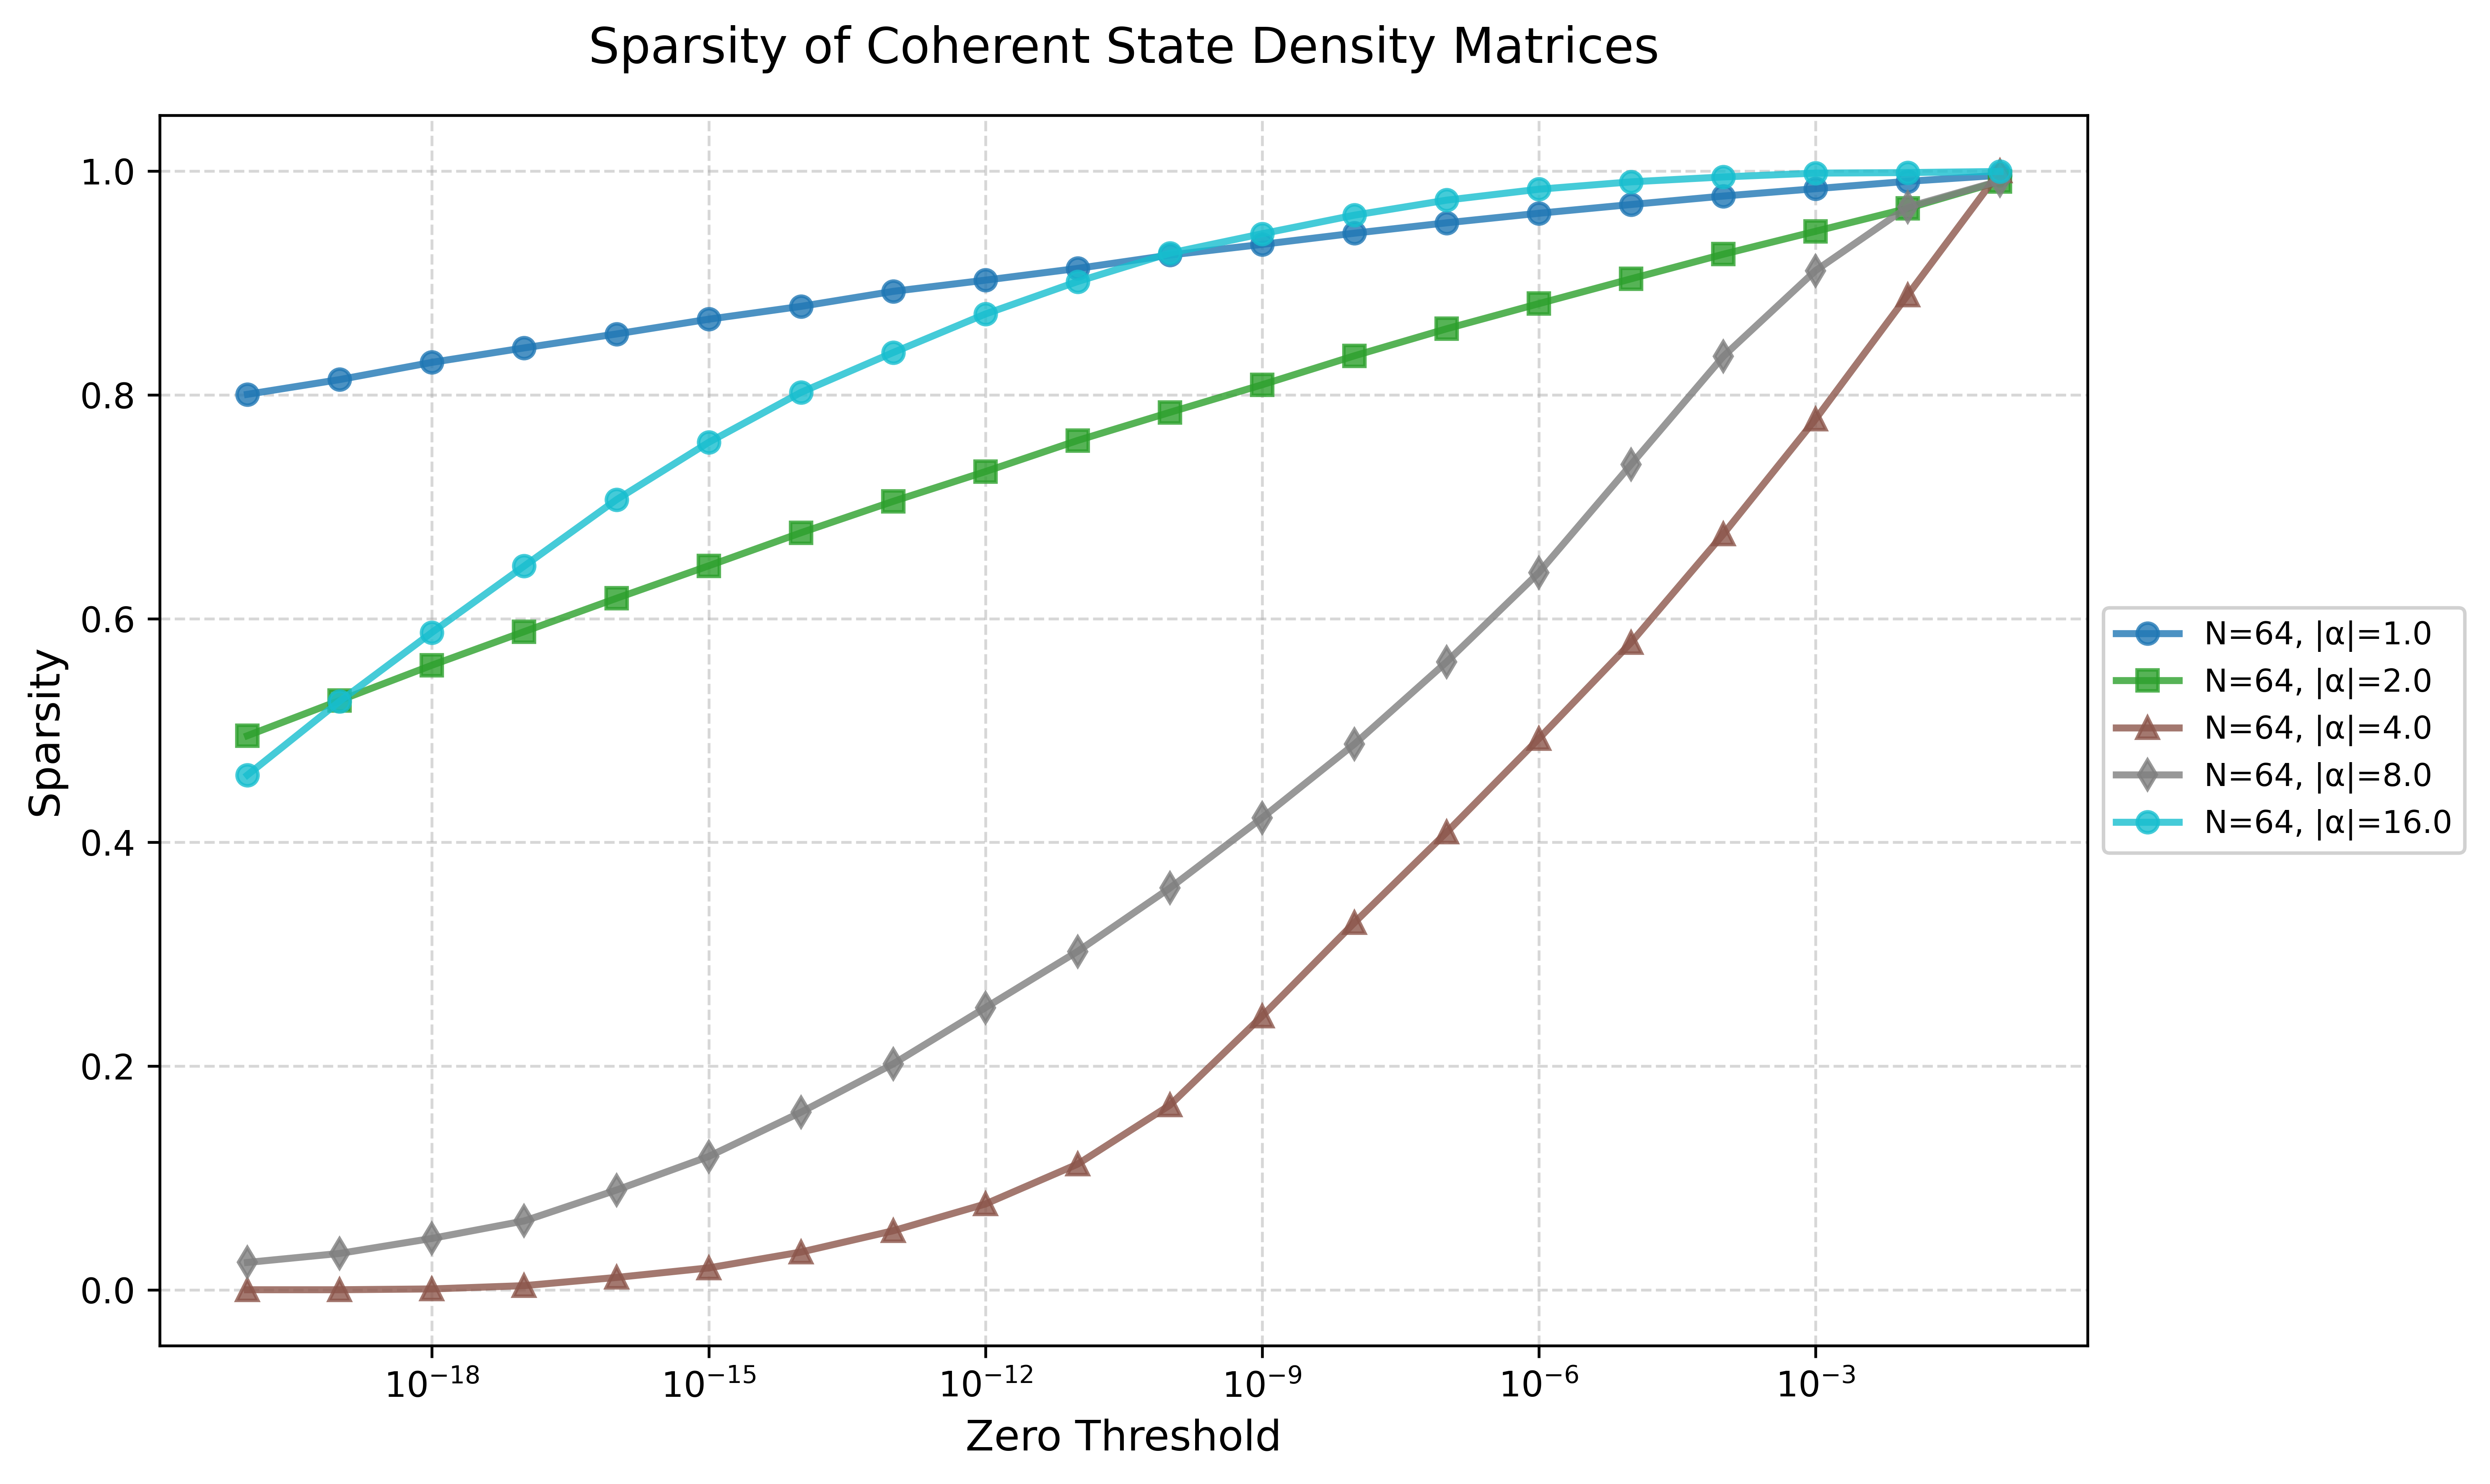

In [16]:
results = evaluate_sparsity_for_dimensions(
    [64], alpha_scales, thresholds, alpha_base
)

### Discrimination of coherent states: preliminary explorations

In [ ]:
from utils.handy_states import *


NameError: name 'asymm_states' is not defined

#### Pure state unambiguous discrimination

In [ ]:
# Define alpha_arr again
# in case for changes later.
alpha_arr = [np.exp((2 * i + 1) / 4 * np.pi * 1j) for i in range(4)]

In [ ]:
coh_states_pure = [
    coherent(N=32, alpha=(alpha * 8))
    .data.to_array()
    .flatten()
    for alpha in alpha_arr
]

In [ ]:
print(len(coh_states_pure[0]))
print(coh_states_pure[0][:8])

32
[-1.78600215e-03+1.25038692e-17j  5.10456000e-03+5.10456000e-03j
 -3.44968848e-17-2.00034124e-02j -3.10607176e-02+3.10607176e-02j
  8.12138761e-02-9.79152383e-18j -9.25301602e-02-9.25301602e-02j
  1.75306555e-16+1.88072084e-01j  1.73491118e-01-1.73491118e-01j]


In [ ]:
# Check they are nonorthogonal, lin_indep

In [ ]:
import sys

sys.path.append("../flow")
from flow.solve_mix import *

problem_coh = ProblemSpec(
    num_qubits=5,
    num_states=4,
    seed=33,
    case_id="q5_n4_cohN32a8",
    prior_prob=[0.25] * 4, # Old method requires negation
    state_type="statevector",
)

In [ ]:
from flow import solvers
problem_coh.set_states(
    state_type="statevector",
    states=coh_states_pure,
    overwrite=True,
)
problem_coh.is_lin_indep()

povm_vectors_recip = solvers.apply_Eldar(
    problem_spec=problem_coh,
    prior_prob=[-0.25] * 4, # Old method requires negation
)

Rank = 4
#states = 4


In [ ]:
last_op = np.eye(32, dtype="complex128")
op_list = []
for m in povm_vectors_recip:
    # Add "None" to transpose
    # https://stackoverflow.com/a/11885718/13518808
    op = np.multiply(m[None].T.conj(), m)
    op_list.append(op)
    last_op -= op
op_list.append(last_op)

In [ ]:
bitstring_to_target_state = dict()

povm = []
strings_used = 0
print(op_list[-1])
for i in range(len(op_list)):
    # print(op_list[i])
    u, s, v = np.linalg.svd(op_list[i], hermitian=True)
    print(len(s))
    for j in range(len(s)):
        # Don't add if s[j] too small
        if s[j] > 1e-7:
            last_povm = u[:, j] * np.sqrt(s[j])
            bitstring_to_target_state[strings_used] = i
            povm.append(last_povm.conj())
            strings_used += 1

[[ 9.9999e-01+0.0000e+00j  5.1144e-18-5.1008e-18j  0.0000e+00+2.0017e-17j
  ... -2.5801e-18+6.1393e-18j  0.0000e+00-2.9570e-18j
   2.9443e-18+2.9375e-18j]
 [ 5.1144e-18+5.1008e-18j  9.9979e-01+0.0000e+00j  1.2197e-19+0.0000e+00j
  ...  1.7782e-04+1.0205e-17j -2.0329e-20+0.0000e+00j
   2.0769e-22-3.3881e-21j]
 [ 0.0000e+00-2.0017e-17j  1.2197e-19+0.0000e+00j  9.9840e-01+0.0000e+00j
  ...  1.9922e-17+2.0017e-17j  2.3665e-04+0.0000e+00j
  -4.7434e-20-2.7105e-20j]
 ...
 [-2.5801e-18-6.1393e-18j  1.7782e-04-1.0203e-17j  1.9922e-17-2.0017e-17j
  ...  9.9985e-01+3.8950e-22j -2.9443e-18+2.9561e-18j
  -2.2710e-21+6.7763e-21j]
 [ 0.0000e+00+2.9570e-18j -2.0329e-20+0.0000e+00j  2.3665e-04+0.0000e+00j
  ... -2.9443e-18-2.9561e-18j  9.9997e-01+0.0000e+00j
   1.0164e-20-1.6941e-21j]
 [ 2.9443e-18-2.9375e-18j  2.0769e-22+3.3881e-21j -4.7434e-20+2.7105e-20j
  ... -2.2710e-21-3.3881e-21j  1.0164e-20+1.6941e-21j
   9.9993e-01-8.5587e-22j]]
32
32
32
32
32


In [ ]:
bitstring_to_target_state

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 4,
 6: 4,
 7: 4,
 8: 4,
 9: 4,
 10: 4,
 11: 4,
 12: 4,
 13: 4,
 14: 4,
 15: 4,
 16: 4,
 17: 4,
 18: 4,
 19: 4,
 20: 4,
 21: 4,
 22: 4,
 23: 4,
 24: 4,
 25: 4,
 26: 4,
 27: 4,
 28: 4,
 29: 4,
 30: 4,
 31: 4,
 32: 4,
 33: 4,
 34: 4,
 35: 4}

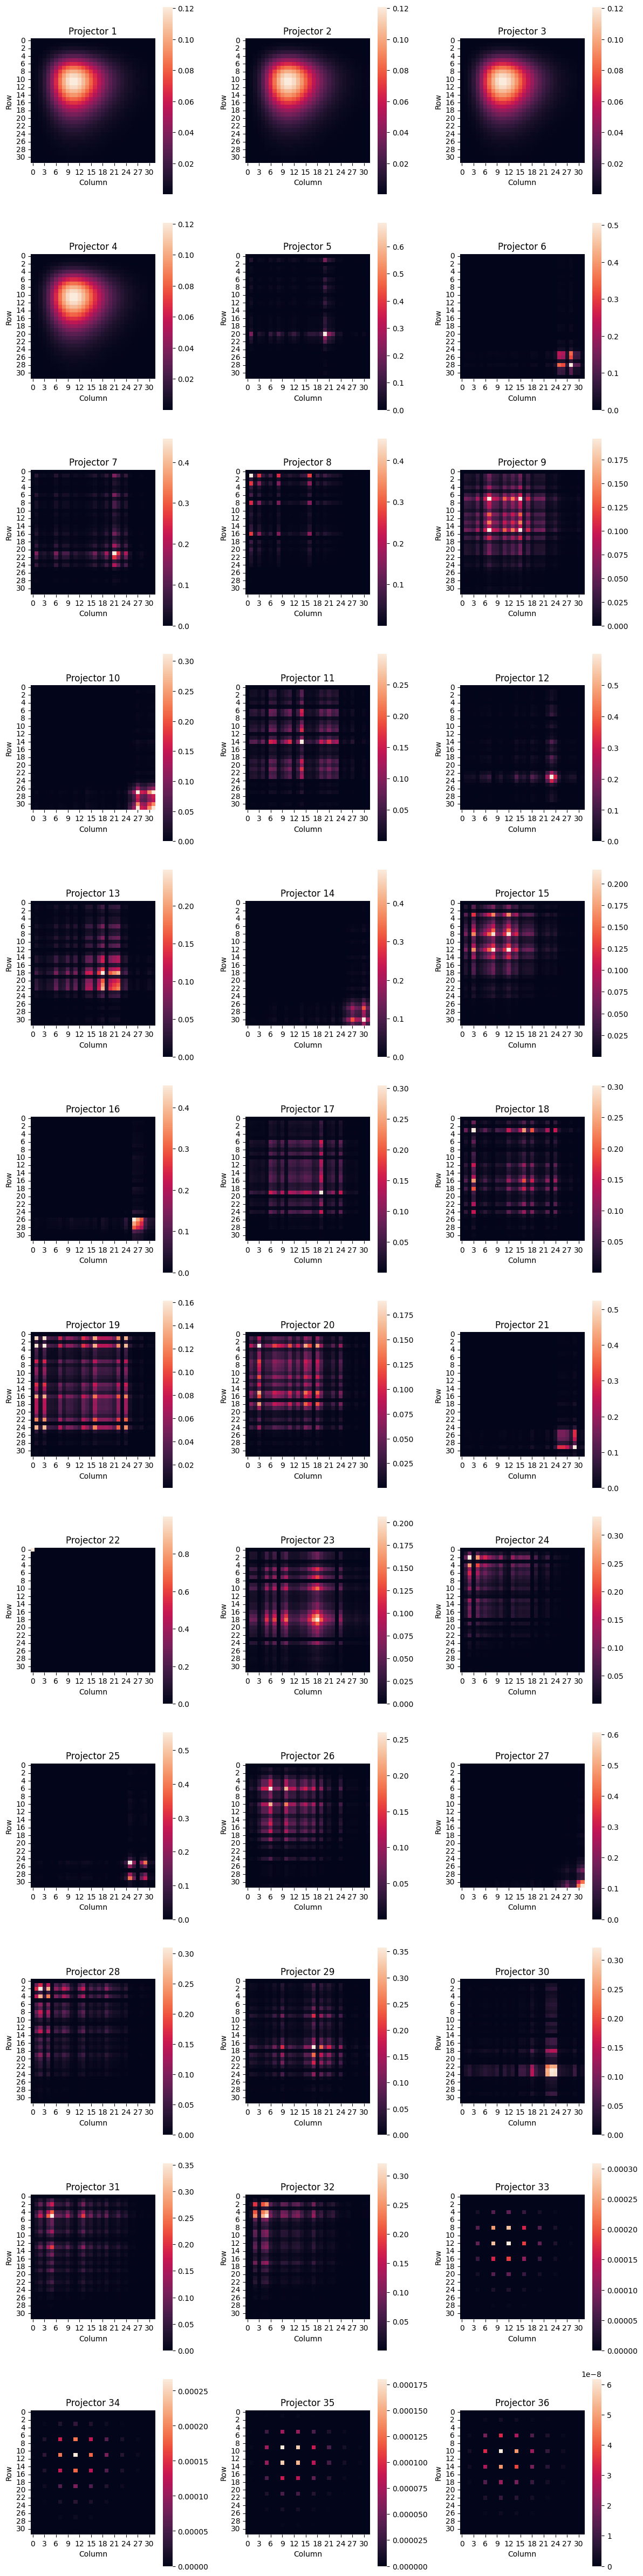

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Draw projector
# Decompose to Rank-1
# op = np.multiply(vec[None].T.conj(), vec)

# Assuming povm is a list of vectors (e.g., numpy arrays)
# Example: povm = [np.array([1, 0]), np.array([0, 1])] for a 2D case
# Replace with your actual povm data
# povm = [np.array([1, 0]), np.array([0, 1])]  # Placeholder for demonstration

# Set up the figure and subplots
n = len(povm)  # Number of POVM elements
cols = min(n, 3)  # Max 3 columns for layout (adjust as needed)
rows = (n + cols - 1) // cols  # Calculate rows needed
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), squeeze=False)

# Flatten axes array for easier iteration
axes = axes.flatten()

for i, vec in enumerate(povm):
    # Compute the rank-1 projector: |v><v|
    op = np.outer(vec.conj(), vec)  # Equivalent to vec[None].T.conj() @ vec[None]
    
    # Plot heatmap on the corresponding subplot
    sns.heatmap(np.abs(op), ax=axes[i], fmt='.2f', square=True)
    axes[i].set_title(f'Projector {i+1}')
    axes[i].set_xlabel('Column')
    axes[i].set_ylabel('Row')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from flow.verify_povm import verify_povm
verify_povm(povm=povm)

<class 'numpy.ndarray'>


True

#### Mixed state epsilon-unambiguous discrimination

In [ ]:
coh_states_pure_dm = [coherent_dm(N=32, alpha=alpha * 8).data.to_array() for alpha in alpha_arr]

First, let's evaluate the previous POVM derived from the reciprocal states

In [ ]:
# Read results
from flow.plots import calculate_prob_matrix
probability_matrix = calculate_prob_matrix(
    [0.25] * 4, povm, coh_states_pure_dm, bitstring_to_target_state, strings_used
)

Text(0.5, 1.0, ', $\\alpha=\\beta=0.88$')

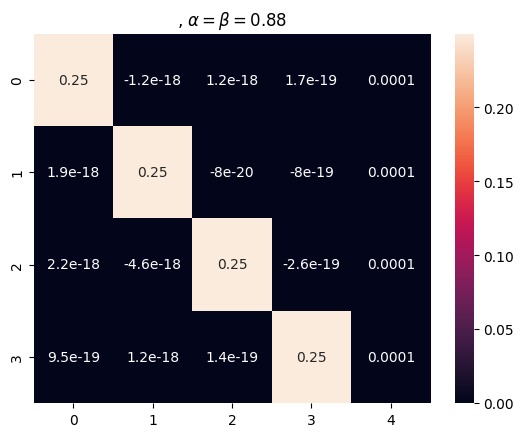

In [ ]:
from seaborn import heatmap
heatmap(probability_matrix, annot=True)
plt.title(r", $\alpha=\beta=0.88$")

In [ ]:
problem_coh.set_states(
    state_type="densitymatrix",
    states=coh_states_pure_dm,
    overwrite=True,
)

print(0)
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.01] * 4,
    beta=[0.01] * 4,
)

0


Result = 0.9999999828715433
CVXPY returns optimal
Solution for PI_0 =
[[ 2.0000e-01+0.0000e+00j -9.1155e-06+9.1155e-06j  4.0614e-16-3.5728e-05j
  ...  7.7791e-06-7.7791e-06j  6.1201e-16+5.2805e-06j
  -5.2513e-06-5.2513e-06j]
 [-9.1155e-06-9.1155e-06j  2.0001e-01+0.0000e+00j -1.0213e-04+1.0213e-04j
  ... -8.8946e-06+2.2689e-17j  1.5094e-05-1.5094e-05j
   3.3169e-17+3.0022e-05j]
 [ 4.0614e-16+3.5728e-05j -1.0213e-04-1.0213e-04j  2.0008e-01+0.0000e+00j
  ...  8.7157e-05+8.7157e-05j -1.1833e-05-2.1485e-17j
   5.8836e-05-5.8836e-05j]
 ...
 [ 7.7791e-06+7.7791e-06j -8.8946e-06-2.2689e-17j  8.7157e-05-8.7157e-05j
  ...  2.0001e-01+0.0000e+00j -1.2881e-05+1.2881e-05j
   2.7037e-15-2.5621e-05j]
 [ 6.1201e-16-5.2805e-06j  1.5094e-05+1.5094e-05j -1.1833e-05+2.1485e-17j
  ... -1.2881e-05-1.2881e-05j  2.0000e-01+0.0000e+00j
  -8.6956e-06+8.6956e-06j]
 [-5.2513e-06+5.2513e-06j  3.3169e-17-3.0022e-05j  5.8836e-05+5.8836e-05j
  ...  2.7037e-15+2.5621e-05j -8.6956e-06-8.6956e-06j
   2.0000e-01+0.0000e+

In [ ]:
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.001] * 4,
    beta=[0.001] * 4,
)

Result = 0.999999976794814
CVXPY returns optimal
Solution for PI_0 =
[[ 2.0000e-01+0.0000e+00j -9.1155e-06+9.1155e-06j  8.6386e-16-3.5728e-05j
  ...  7.7791e-06-7.7791e-06j  9.6357e-15+5.2805e-06j
  -5.2513e-06-5.2513e-06j]
 [-9.1155e-06-9.1155e-06j  2.0001e-01+0.0000e+00j -1.0213e-04+1.0213e-04j
  ... -8.8946e-06+6.0033e-15j  1.5094e-05-1.5094e-05j
  -1.5281e-14+3.0022e-05j]
 [ 8.6386e-16+3.5728e-05j -1.0213e-04-1.0213e-04j  2.0008e-01+0.0000e+00j
  ...  8.7157e-05+8.7157e-05j -1.1833e-05+3.8947e-15j
   5.8836e-05-5.8836e-05j]
 ...
 [ 7.7791e-06+7.7791e-06j -8.8946e-06-6.0033e-15j  8.7157e-05-8.7157e-05j
  ...  2.0001e-01+0.0000e+00j -1.2881e-05+1.2881e-05j
  -3.1287e-15-2.5621e-05j]
 [ 9.6357e-15-5.2805e-06j  1.5094e-05+1.5094e-05j -1.1833e-05-3.8947e-15j
  ... -1.2881e-05-1.2881e-05j  2.0000e-01+0.0000e+00j
  -8.6956e-06+8.6956e-06j]
 [-5.2513e-06+5.2513e-06j -1.5281e-14-3.0022e-05j  5.8836e-05+5.8836e-05j
  ... -3.1287e-15+2.5621e-05j -8.6956e-06-8.6956e-06j
   2.0000e-01+0.0000e+0

In [ ]:
probability_matrix_crossQD = calculate_prob_matrix(
    [0.25] * 4,
    result[0],
    coh_states_pure_dm,
    problem_coh.bitstring_to_target_state,
    len(result[0]),
)

<Axes: >

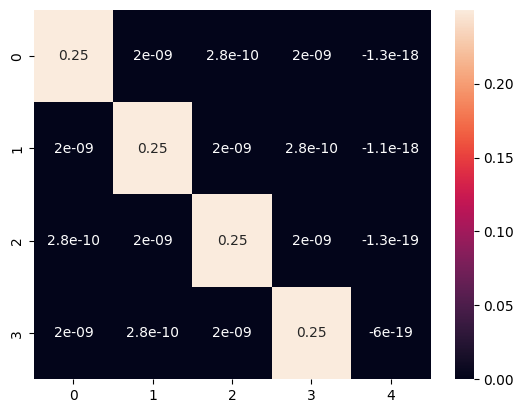

In [ ]:
heatmap(probability_matrix_crossQD, annot=True)

Maybe this case is too easy, but it already shows that our formulation may benefit in some situations.

In [ ]:
result_emp = apply_Eldar_mix_primal(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    beta=0,
)

Result = 0.9999999828715571
CVXPY returns optimal
Solution for PI_0 =
[[ 2.0000e-01+0.0000e+00j -9.1155e-06+9.1155e-06j -1.9803e-16-3.5729e-05j
  ...  7.7791e-06-7.7791e-06j -9.7616e-17+5.2805e-06j
  -5.2513e-06-5.2513e-06j]
 [-9.1155e-06-9.1155e-06j  2.0001e-01+0.0000e+00j -1.0213e-04+1.0213e-04j
  ... -8.8947e-06-2.1698e-16j  1.5094e-05-1.5094e-05j
   9.4199e-16+3.0022e-05j]
 [-1.9803e-16+3.5729e-05j -1.0213e-04-1.0213e-04j  2.0008e-01+0.0000e+00j
  ...  8.7157e-05+8.7157e-05j -1.1833e-05-9.3739e-16j
   5.8836e-05-5.8836e-05j]
 ...
 [ 7.7791e-06+7.7791e-06j -8.8947e-06+2.1698e-16j  8.7157e-05-8.7157e-05j
  ...  2.0001e-01+0.0000e+00j -1.2881e-05+1.2881e-05j
  -1.7107e-15-2.5621e-05j]
 [-9.7616e-17-5.2805e-06j  1.5094e-05+1.5094e-05j -1.1833e-05+9.3739e-16j
  ... -1.2881e-05-1.2881e-05j  2.0000e-01+0.0000e+00j
  -8.6957e-06+8.6957e-06j]
 [-5.2513e-06+5.2513e-06j  9.4199e-16-3.0022e-05j  5.8836e-05+5.8836e-05j
  ... -1.7107e-15+2.5621e-05j -8.6957e-06-8.6957e-06j
   2.0000e-01+0.0000e+

<Axes: >

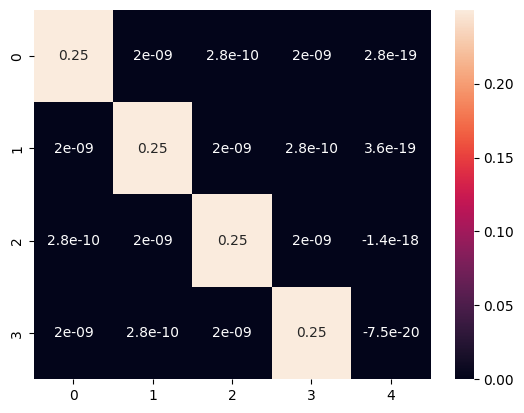

In [ ]:
probability_matrix_Eldar = calculate_prob_matrix(
    [0.25] * 4,
    result_emp[0],
    coh_states_pure_dm,
    problem_coh.bitstring_to_target_state,
    len(result_emp[0]),
)
heatmap(probability_matrix_Eldar, annot=True)

##### Add Noise

In [ ]:
noise_level = 0.3

disturbance_states = [
    DensityMatrix(ProblemSpec.depolarizing_noise_channel(5)) for _ in range(4)
]
# Combine these

combined_states = [
    (1 - noise_level) * coh_states_pure_dm[_]
    + noise_level * disturbance_states[_].data
    for _ in range(4)
]

#### Another case

In [ ]:
coh_states_pure_dm_1 = [coherent_dm(N=32, alpha=alpha).data.to_array() for alpha in alpha_arr]
coh_states_pure_1 = [coherent(N=32, alpha=alpha).data.to_array().flatten() for alpha in alpha_arr]

In [ ]:
noise_level = 0.3

disturbance_states = [
    DensityMatrix(ProblemSpec.depolarizing_noise_channel(5)) for _ in range(4)
]
# Combine these

coh_states_pure_dm_1_noise = [
    (1 - noise_level) * coh_states_pure_dm_1[_]
    + noise_level * disturbance_states[_].data
    for _ in range(4)
]

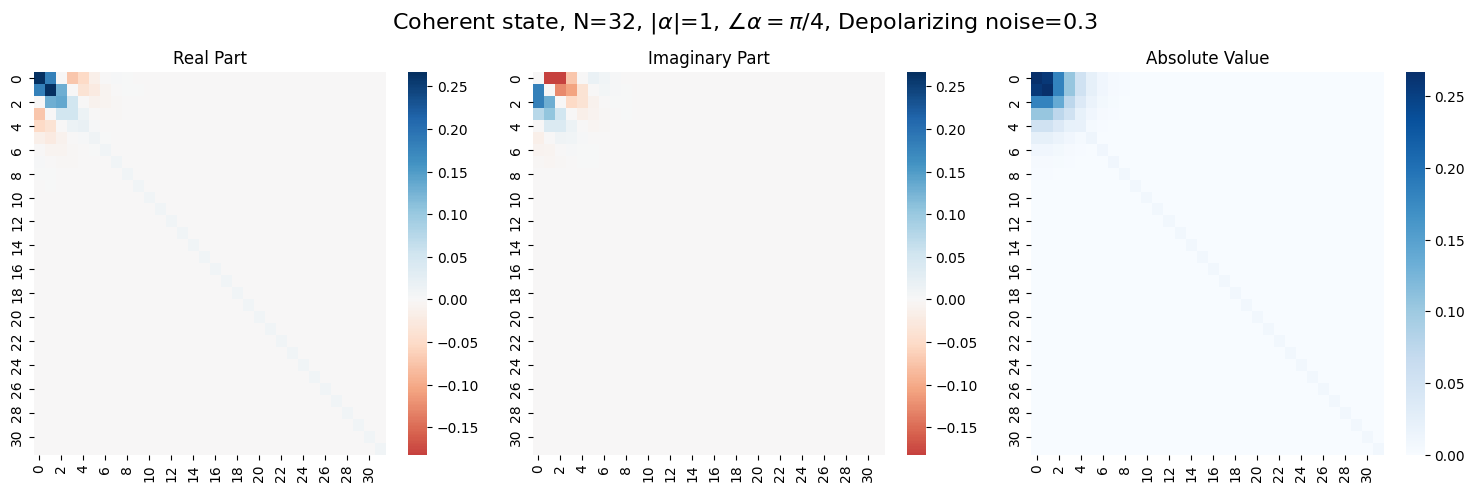

In [ ]:
c_heatmap.plot(
    coh_states_pure_dm_1_noise[0],
    annot=False,
    title=r"Coherent state, N=32, $|\alpha|$=1, $\angle{\alpha}=\pi/4$, Depolarizing noise=0.3",
    show_phase=False,
)

In [ ]:
from flow import solvers
problem_coh.set_states(
    state_type="statevector",
    states=coh_states_pure_1,
    overwrite=True,
)
problem_coh.is_lin_indep()

povm_vectors_recip = solvers.apply_Eldar(
    problem_spec=problem_coh,
    prior_prob=[-0.25] * 4, # Old method requires negation
)

Rank = 4
#states = 4


In [ ]:
last_op = np.eye(32, dtype="complex128")
op_list = []
for m in povm_vectors_recip:
    # Add "None" to transpose
    # https://stackoverflow.com/a/11885718/13518808
    op = np.multiply(m[None].T.conj(), m)
    op_list.append(op)
    last_op -= op
op_list.append(last_op)

In [ ]:
bitstring_to_target_state = dict()

povm = []
strings_used = 0
print(op_list[-1])
for i in range(len(op_list)):
    # print(op_list[i])
    u, s, v = np.linalg.svd(op_list[i], hermitian=True)
    print(len(s))
    for j in range(len(s)):
        # Don't add if s[j] too small
        if s[j] > 1e-7:
            last_povm = u[:, j] * np.sqrt(s[j])
            bitstring_to_target_state[strings_used] = i
            povm.append(last_povm.conj())
            strings_used += 1

[[ 8.4622e-01+0.0000e+00j  2.4286e-17-2.5327e-16j  0.0000e+00+1.1310e-15j
  ...  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
   0.0000e+00+0.0000e+00j]
 [ 2.4286e-17+2.5327e-16j  8.3588e-01+3.6213e-19j -1.2490e-16-5.0654e-16j
  ...  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
   0.0000e+00+0.0000e+00j]
 [ 0.0000e+00-1.1310e-15j -1.2490e-16+5.0654e-16j  6.6812e-01+0.0000e+00j
  ...  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
   0.0000e+00+0.0000e+00j]
 ...
 [ 0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
  ...  1.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
   0.0000e+00+0.0000e+00j]
 [ 0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
  ...  0.0000e+00+0.0000e+00j  1.0000e+00+0.0000e+00j
   0.0000e+00+0.0000e+00j]
 [ 0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
  ...  0.0000e+00+0.0000e+00j  0.0000e+00+0.0000e+00j
   1.0000e+00+0.0000e+00j]]
32
32
32
32
32


In [ ]:
probability_matrix = calculate_prob_matrix(
    [0.25] * 4, povm, coh_states_pure_dm_1, bitstring_to_target_state, strings_used
)

<Axes: >

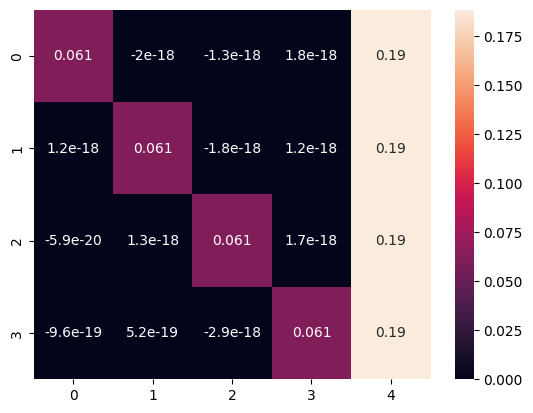

In [ ]:
heatmap(probability_matrix, annot=True)

<Axes: >

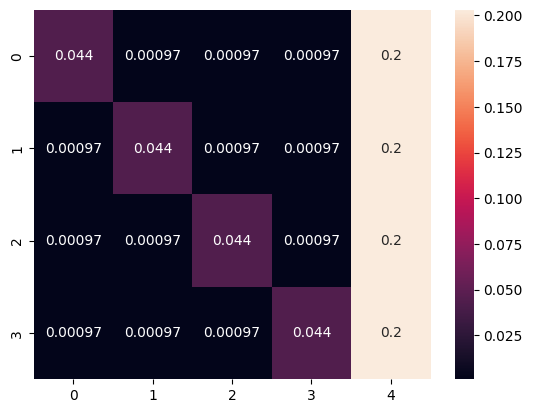

In [ ]:
probability_matrix_noise = calculate_prob_matrix(
    [0.25] * 4, povm, coh_states_pure_dm_1_noise, bitstring_to_target_state, strings_used
)
heatmap(probability_matrix_noise, annot=True)

In [ ]:
0.00097 * 3 / (0.044 + 0.00097 * 3)

0.062033681517800046

In [ ]:
problem_coh.set_states(
    state_type="densitymatrix",
    states=coh_states_pure_dm_1_noise,
    overwrite=True,
)

In [ ]:
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.06] * 4,
    beta=[0.06] * 4,
)

Result = 0.21802552576932446
CVXPY returns optimal
Solution for PI_0 =
[[ 5.2058e-02+0.0000e+00j  3.7997e-02-3.7997e-02j -1.2162e-14-7.4475e-02j
  ... -4.2640e-17+1.6178e-16j -7.6182e-16-4.0312e-17j
  -1.1232e-16-5.2767e-18j]
 [ 3.7997e-02+3.7997e-02j  5.5468e-02+0.0000e+00j  5.4359e-02-5.4359e-02j
  ...  1.3353e-16-1.2426e-15j  4.1723e-16-1.2114e-16j
  -8.3221e-17+1.0776e-15j]
 [-1.2162e-14+7.4475e-02j  5.4359e-02+5.4359e-02j  1.0655e-01+0.0000e+00j
  ... -2.5693e-16-2.2051e-16j -2.6690e-16-9.7907e-17j
   6.5942e-16-7.3274e-16j]
 ...
 [-4.2640e-17-1.6178e-16j  1.3353e-16+1.2426e-15j -2.5693e-16+2.2051e-16j
  ...  9.5937e-10+0.0000e+00j  4.6141e-15+6.2983e-15j
  -1.1736e-14-1.5685e-14j]
 [-7.6182e-16+4.0312e-17j  4.1723e-16+1.2114e-16j -2.6690e-16+9.7907e-17j
  ...  4.6141e-15-6.2983e-15j  9.5972e-10+0.0000e+00j
   8.3934e-16-6.3974e-15j]
 [-1.1232e-16+5.2767e-18j -8.3221e-17-1.0776e-15j  6.5942e-16+7.3274e-16j
  ... -1.1736e-14+1.5685e-14j  8.3934e-16+6.3974e-15j
   9.5943e-10+0.0000e

In [ ]:
probability_matrix_crossQD = calculate_prob_matrix(
    [0.25] * 4,
    result[0],
    coh_states_pure_dm_1_noise,
    problem_coh.bitstring_to_target_state,
    len(result[0]),
)

<Axes: >

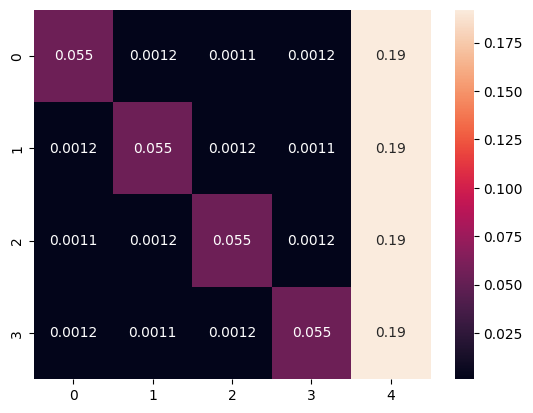

In [ ]:
heatmap(probability_matrix_crossQD, annot=True)

In [ ]:
0.0035 / (0.0035 + 0.055)

0.059829059829059825

In [ ]:
result_emp_1 = apply_Eldar_mix_primal(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    beta=0,
)

Result = 0.7103050090977083
CVXPY returns optimal
Solution for PI_0 =
[[ 2.5000e-01+0.0000e+00j  1.7249e-01-1.7249e-01j  6.9797e-17-2.4461e-01j
  ... -4.9776e-17+4.7011e-17j -5.6575e-18+2.4051e-17j
   1.7291e-17+1.5221e-17j]
 [ 1.7249e-01+1.7249e-01j  2.5000e-01+0.0000e+00j  1.7580e-01-1.7580e-01j
  ... -5.3020e-18+6.9540e-18j -1.1304e-17+2.0665e-18j
  -3.8682e-18+8.5524e-18j]
 [ 6.9797e-17+2.4461e-01j  1.7580e-01+1.7580e-01j  2.5000e-01+0.0000e+00j
  ... -5.6404e-17-5.2723e-17j  2.3357e-18-2.2885e-18j
  -1.0596e-17+3.2559e-18j]
 ...
 [-4.9776e-17-4.7011e-17j -5.3020e-18-6.9540e-18j -5.6404e-17+5.2723e-17j
  ...  2.5000e-01+0.0000e+00j -4.7721e-16+7.7731e-16j
  -1.3218e-15-4.9959e-18j]
 [-5.6575e-18-2.4051e-17j -1.1304e-17-2.0665e-18j  2.3357e-18+2.2885e-18j
  ... -4.7721e-16-7.7731e-16j  2.5000e-01+0.0000e+00j
   3.1195e-16-2.2995e-16j]
 [ 1.7291e-17-1.5221e-17j -3.8682e-18-8.5524e-18j -1.0596e-17-3.2559e-18j
  ... -1.3218e-15+4.9959e-18j  3.1195e-16+2.2995e-16j
   2.5000e-01+0.0000e+

<Axes: >

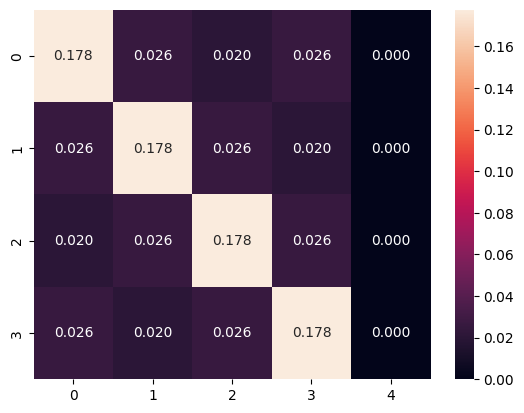

In [ ]:
probability_matrix_Eldar_1 = calculate_prob_matrix(
    [0.25] * 4,
    result_emp_1[0],
    coh_states_pure_dm_1_noise,
    problem_coh.bitstring_to_target_state,
    len(result_emp_1[0]),
)
heatmap(probability_matrix_Eldar_1, annot=True, fmt='.3f')

In [ ]:
0.072 / (0.178 + 0.072)

0.288

In [ ]:
result_emp_1_1 = apply_Eldar_mix_primal(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    beta=0.5,
)

Result = 0.45580480966084547
CVXPY returns optimal
Solution for PI_0 =
[[ 1.3366e-01+0.0000e+00j  9.7561e-02-9.7561e-02j -5.5767e-18-1.8254e-01j
  ... -1.1241e-17+4.9731e-17j  2.3377e-17+3.3265e-17j
   3.2379e-17+1.8887e-17j]
 [ 9.7561e-02+9.7561e-02j  1.4242e-01+0.0000e+00j  1.3324e-01-1.3324e-01j
  ... -4.5413e-17+2.4837e-17j -3.1756e-18+2.4525e-17j
   1.9685e-17+2.4962e-17j]
 [-5.5767e-18+1.8254e-01j  1.3324e-01+1.3324e-01j  2.4931e-01+0.0000e+00j
  ... -9.1938e-17-3.4254e-17j -5.1452e-17+2.9298e-17j
  -3.5186e-17+4.2974e-17j]
 ...
 [-1.1241e-17-4.9731e-17j -4.5413e-17-2.4837e-17j -9.1938e-17+3.4254e-17j
  ... -3.5284e-12+0.0000e+00j  1.7355e-16-1.6439e-16j
  -1.8505e-16-6.2800e-17j]
 [ 2.3377e-17-3.3265e-17j -3.1756e-18-2.4525e-17j -5.1452e-17-2.9298e-17j
  ...  1.7355e-16+1.6439e-16j -3.5282e-12+0.0000e+00j
  -6.7378e-17-2.2732e-16j]
 [ 3.2379e-17-1.8887e-17j  1.9685e-17-2.4962e-17j -3.5186e-17-4.2974e-17j
  ... -1.8505e-16+6.2800e-17j -6.7378e-17+2.2732e-16j
  -3.5284e-12+0.0000e

Text(0.5, 1.0, 'Eldar, $\\beta=0.5$')

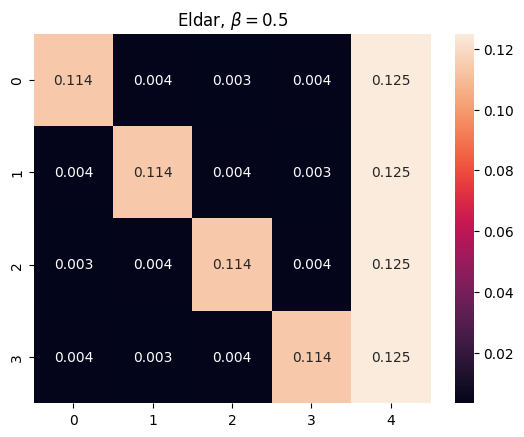

In [ ]:
probability_matrix_Eldar_1 = calculate_prob_matrix(
    [0.25] * 4,
    result_emp_1_1[0],
    coh_states_pure_dm_1_noise,
    problem_coh.bitstring_to_target_state,
    len(result_emp_1_1[0]),
)
heatmap(probability_matrix_Eldar_1, annot=True, fmt='.3f')
plt.title(r"Eldar, $\beta=0.5$")

In [ ]:
0.011 / (0.011 + 0.114)

0.088

In [ ]:
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.088] * 4,
    beta=[0.088] * 4,
)

Result = 0.45328910781625703
CVXPY returns optimal
Solution for PI_0 =
[[ 1.3237e-01+0.0000e+00j  9.6623e-02-9.6623e-02j -5.9561e-16-1.8166e-01j
  ... -3.3861e-17+3.4974e-17j -5.6336e-18+2.1555e-17j
   1.2279e-18+9.1271e-18j]
 [ 9.6623e-02+9.6623e-02j  1.4105e-01+0.0000e+00j  1.3260e-01-1.3260e-01j
  ... -5.3251e-17+2.1585e-18j -9.4527e-18+4.8604e-18j
  -3.3910e-18+1.9999e-17j]
 [-5.9561e-16+1.8166e-01j  1.3260e-01+1.3260e-01j  2.4931e-01+0.0000e+00j
  ... -4.8597e-17-5.6016e-17j -3.0178e-17+7.1904e-18j
   8.9054e-18+5.7766e-18j]
 ...
 [-3.3861e-17-3.4974e-17j -5.3251e-17-2.1585e-18j -4.8597e-17+5.6016e-17j
  ... -2.0879e-10+0.0000e+00j -4.5741e-17-6.9751e-17j
  -3.9166e-16-3.0977e-16j]
 [-5.6336e-18-2.1555e-17j -9.4527e-18-4.8604e-18j -3.0178e-17-7.1904e-18j
  ... -4.5741e-17+6.9751e-17j -2.0879e-10+0.0000e+00j
  -3.1750e-17-2.4584e-16j]
 [ 1.2279e-18-9.1271e-18j -3.3910e-18-1.9999e-17j  8.9054e-18-5.7766e-18j
  ... -3.9166e-16+3.0977e-16j -3.1750e-17+2.4584e-16j
  -2.0879e-10+0.0000e

Text(0.5, 1.0, 'CrossQD, $\\alpha=\\beta=0.88$')

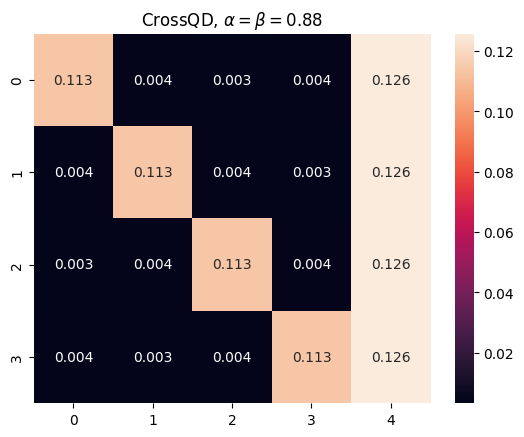

In [ ]:
probability_matrix_crossQD_1_noise = calculate_prob_matrix(
    [0.25] * 4,
    result[0],
    coh_states_pure_dm_1_noise,
    problem_coh.bitstring_to_target_state,
    len(result[0]),
)
heatmap(probability_matrix_crossQD_1_noise, annot=True, fmt='.3f')
plt.title(r"CrossQD, $\alpha=\beta=0.88$")

## Check the influence of different overlaps in two coherent states

In [ ]:
# Different phases
# Draft by ChatGPT 4o, revised by Grok 3
import numpy as np

def cut_pi(num_pieces):
    """
    Divide the interval [0, π] into num_pieces equal parts, including 0 and π.
    
    Args:
        num_pieces (int): Number of equal parts to divide [0, π] into. Must be positive.
    
    Returns:
        numpy.ndarray: Array of num_pieces evenly spaced angles in [0, π].
    
    Raises:
        ValueError: If num_pieces is not a positive integer.
    """
    if not isinstance(num_pieces, int) or num_pieces <= 0:
        raise ValueError("num_pieces must be a positive integer")
    
    # Generate num_pieces points from 0 to π
    return np.linspace(0, np.pi, num_pieces + 1)

# Example usage
try:
    angles = cut_pi(8)
    print("Angles (radians):", angles)
    print("Angles (in units of π):", angles / np.pi)
except ValueError as e:
    print("Error:", e)

Angles (radians): [0.     0.3927 0.7854 1.1781 1.5708 1.9635 2.3562 2.7489 3.1416]
Angles (in units of π): [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]


In [ ]:
alpha_arr = [np.exp(angles[i] * 1j) for i in range(8)]

In [ ]:
angles = cut_pi(16)
alpha_arr = [np.exp(angles[i] * 1j) for i in range(8)]

In [ ]:
problem_2coh_32 = ProblemSpec(
    num_qubits=5,
    num_states=2,
    seed=33,
    case_id="q5_n4_cohN32a8",
    prior_prob=[0.5] * 2, # Old method requires negation
    state_type="statevector",
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import multiprocessing as mp


# Function to compute result for a single idx
def compute_result(idx, eps=1e-7):
    states = [
        coherent_dm(N=32, alpha=alpha_arr[0] * 8).data.to_array(),
        coherent_dm(N=32, alpha=alpha_arr[idx] * 8).data.to_array()
    ]
    problem_2coh_32.set_states(
        state_type="densitymatrix",
        states=states,
        overwrite=True,
    )
    result = apply_crossQD(
        problem_spec=problem_2coh_32,
        prior_prob=[0.5] * 2,
        alpha=[eps] * 2,
        beta=[eps] * 2,
    )
    return result

# Parallelize computation across all idx values
n_jobs = mp.cpu_count()  # Use all available CPU cores
results = Parallel(n_jobs=n_jobs)(
    delayed(compute_result)(idx) for idx in range(1, len(alpha_arr))
)

# Convert results to NumPy array for plotting
results_arr = []
for result in results:
    _, b, c, d = result
    results_arr.append([b, c, d])
# results = np.array(results[:][1:])  # Shape: (len(alpha_arr), 3)
results_arr = np.array(results_arr)

Result = 0.9999998228521765
CVXPY returns optimal
Solution for PI_0 =
[[ 3.3333e-01+0.0000e+00j -7.7576e-06-4.2145e-06j  3.4821e-05+4.5492e-06j
  ... -9.3738e-06-3.0479e-06j  5.1459e-06-6.7498e-07j
  -4.4675e-06+2.4297e-06j]
 [-7.7576e-06+4.2145e-06j  3.3335e-01+0.0000e+00j -8.6910e-05-4.7183e-05j
  ...  1.9178e-05+1.0478e-05j -1.8183e-05-5.9102e-06j
   2.9261e-05-3.8334e-06j]
 [ 3.4821e-05-4.5492e-06j -8.6910e-05+4.7183e-05j  3.3347e-01+0.0000e+00j
  ... -4.8031e-05+2.2812e-05j  2.5493e-05+1.3936e-05j
  -7.0867e-05-2.3063e-05j]
 ...
 [-9.3738e-06+3.0479e-06j  1.9178e-05-1.0478e-05j -4.8031e-05-2.2812e-05j
  ...  3.3335e-01+0.0000e+00j -1.0960e-05-5.9522e-06j
   2.4972e-05+3.2681e-06j]
 [ 5.1459e-06+6.7498e-07j -1.8183e-05+5.9102e-06j  2.5493e-05-1.3936e-05j
  ... -1.0960e-05+5.9522e-06j  3.3334e-01+0.0000e+00j
  -7.3960e-06-4.0212e-06j]
 [-4.4675e-06-2.4297e-06j  2.9261e-05+3.8334e-06j -7.0867e-05+2.3063e-05j
  ...  2.4972e-05-3.2681e-06j -7.3960e-06+4.0212e-06j
   3.3334e-01+0.0000e+

/home/koova22/miniconda3/envs/q1/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


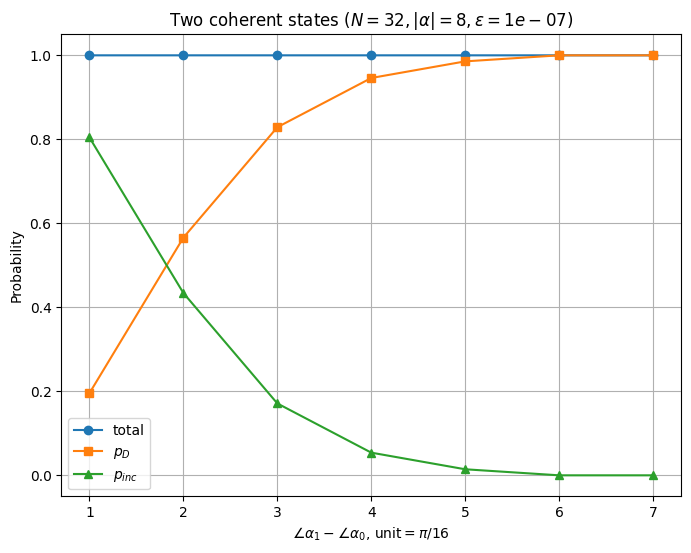

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(alpha_arr)), results_arr[:, 0], label='total', marker='o')
plt.plot(range(1, len(alpha_arr)), results_arr[:, 1], label=r'$p_{D}$', marker='s')
plt.plot(range(1, len(alpha_arr)), results_arr[:, 2], label=r'$p_{inc}$', marker='^')
plt.xlabel(r'$\angle{\alpha_{1}} - \angle{\alpha_{0}}$, unit$=\pi/16$')
plt.ylabel('Probability')
plt.title(rf'Two coherent states ($N=32, |\alpha| = 8, \epsilon=1e-07$)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calculate overlap between the states
from inner_product import inner_products_table

div = 256
angles_test = cut_pi(div)
alpha_arr_test = [np.exp(angles_test[i] * 1j) for i in range(div // 2)]
states_test = [
    coherent_dm(N=32, alpha=alpha_arr_test[i] * 8).data.to_array()
    for i in range(len(alpha_arr_test))
]
inner_products_table(states_test)


Inner Product Table:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

array([[1.0000e+00+0.0000e+00j, 9.9828e-01-8.6736e-19j,
        9.9312e-01-1.0842e-18j, ..., 5.5440e-08+1.7915e-19j,
        4.5924e-08-7.3775e-18j, 3.8267e-08+1.4251e-18j],
       [9.9828e-01+8.6736e-19j, 1.0000e+00+0.0000e+00j,
        9.9828e-01+1.9516e-18j, ..., 6.7342e-08+2.8128e-18j,
        5.5440e-08-1.5966e-18j, 4.5924e-08+3.6113e-18j],
       [9.9312e-01+1.0842e-18j, 9.9828e-01-1.9516e-18j,
        1.0000e+00+0.0000e+00j, ..., 8.2254e-08+9.9088e-18j,
        6.7342e-08-5.1336e-18j, 5.5440e-08-9.6822e-18j],
       ...,
       [5.5440e-08-1.7915e-19j, 6.7342e-08-2.8128e-18j,
        8.2254e-08-9.9088e-18j, ..., 1.0000e+00+0.0000e+00j,
        9.9828e-01+1.7347e-18j, 9.9312e-01-7.5894e-19j],
       [4.5924e-08+7.3775e-18j, 5.5440e-08+1.5966e-18j,
        6.7342e-08+5.1336e-18j, ..., 9.9828e-01-1.7347e-18j,
        1.0000e+00+0.0000e+00j, 9.9828e-01-2.7105e-19j],
       [3.8267e-08-1.4251e-18j, 4.5924e-08-3.6113e-18j,
        5.5440e-08+9.6822e-18j, ..., 9.9312e-01+7.5894e-19j,
 

In [ ]:
# Calculate overlap between the states
from inner_product import inner_products_table

div = 256
angles_test = cut_pi(div)
alpha_arr_test = [np.exp(angles_test[i] * 1j) for i in range(div // 2)]
states_test = [
    coherent_dm(N=32, alpha=alpha_arr_test[i] * 4).data.to_array()
    for i in range(len(alpha_arr_test))
]
inner_products_table(states_test)


Inner Product Table:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

array([[1.0000e+00+0.0000e+00j, 9.9760e-01-6.5052e-19j,
        9.9042e-01+2.0600e-18j, ..., 6.9595e-08+1.6263e-19j,
        6.9916e-08+4.4994e-18j, 7.0250e-08-2.4056e-19j],
       [9.9760e-01+6.5052e-19j, 1.0000e+00+0.0000e+00j,
        9.9760e-01-2.1684e-19j, ..., 6.9279e-08-9.3682e-19j,
        6.9595e-08-2.1989e-18j, 6.9916e-08+4.6553e-18j],
       [9.9042e-01-2.0600e-18j, 9.9760e-01+2.1684e-19j,
        1.0000e+00+0.0000e+00j, ..., 6.8958e-08-1.2536e-18j,
        6.9279e-08+1.7949e-18j, 6.9595e-08-4.8027e-19j],
       ...,
       [6.9595e-08-1.6263e-19j, 6.9279e-08+9.3682e-19j,
        6.8958e-08+1.2536e-18j, ..., 1.0000e+00+0.0000e+00j,
        9.9760e-01-1.3553e-19j, 9.9042e-01-3.7947e-18j],
       [6.9916e-08-4.4994e-18j, 6.9595e-08+2.1989e-18j,
        6.9279e-08-1.7949e-18j, ..., 9.9760e-01+1.3553e-19j,
        1.0000e+00+0.0000e+00j, 9.9760e-01-1.2739e-18j],
       [7.0250e-08+2.4056e-19j, 6.9916e-08-4.6553e-18j,
        6.9595e-08+4.8027e-19j, ..., 9.9042e-01+3.7947e-18j,
 

## Explore the effects of state truncation
We first select the states that are mutually orthogonal, since we know the theoretical 
successful rate of the ideal case of optimal unambiguous discrimination.

In [ ]:
# Different truncation, same alpha
p_succ = []
for i in range(1, 7):
    # different qubits
    # init problem
    problem = ProblemSpec(
        num_qubits=i,
        num_states=2,
        case_id=f"coh_{i}_2",
        prior_prob=[0.5] * 2,
        state_type="densitymatrix",
    )
    # init states
    states = [
        coherent_dm(N=2**i, alpha=alpha_arr[0] * 8).data.to_array(),
        coherent_dm(N=2**i, alpha=alpha_arr[1] * 8).data.to_array(),
    ]
    problem.set_states(
        state_type="densitymatrix",
        states=states,
        overwrite=True,
    )
    # solve
    result = apply_crossQD(
        problem_spec=problem,
        prior_prob=[0.5] * 2,
        alpha=[1e-7] * 2,
        beta=[1e-7] * 2,
    )
    p_succ.append(result[2])
    # explore
    print()

/home/koova22/miniconda3/envs/q1/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Result = 0.0004615473348683608
CVXPY returns optimal_inaccurate
Solution for PI_0 =
[[0.4895+0.j     0.0705-0.0152j]
 [0.0705+0.0152j 0.0106+0.j    ]]
Solution for PI_1 =
[[0.4895+0.j     0.0721+0.0011j]
 [0.0721-0.0011j 0.0106+0.j    ]]
Solution for PI_2 =
[[ 0.021 +0.j    -0.1426+0.014j]
 [-0.1426-0.014j  0.9788+0.j   ]]
bitstring_to_target_state
{0: 0, 1: 0, 2: 1, 3: 1, 4: 2}
strings_used
5
Probabilities for each state:
[0.00023236195284521727, 1.5882854760760624e-06, 1.2820769793717056e-06, 1.5897545271328905e-06, 0.49976953400967294]
[1.2820769787840706e-06, 1.5897545307055348e-06, 0.00023236195297173215, 1.58828547250673e-06, 0.49976953400954716]
Total probability = 1.0000
Success probability = 0.0005
Inconclusive probability = 0.9995


Result = 0.007106503998886666
CVXPY returns optimal_inaccurate
Solution for PI_0 =
[[0.0494+0.j     0.0983-0.023j  0.0054-0.0023j 0.0875-0.0535j]
 [0.0983+0.023j  0.332 +0.j     0.0013+0.0002j 0.0385+0.0013j]
 [0.0054+0.0023j 0.0013-0.0002j 0.3335

In [ ]:
print((angles[1] - angles[0]) / (np.pi / 16))
# TODO compare with theoretical value and overlap

print(p_succ)

1.0
[0.0004679004767655322, 0.007111968972949091, 0.06769769625958666, 0.0006230197736995807, 0.19563015348807788, 0.3109122470118769]


In [ ]:
# for i in range(1, 12):
#     for j in range(len(alpha_scales)):
#         state_0 = coherent(N=2**i, alpha=alpha_arr[0] * alpha_scales[j]).data.to_array().flatten()
#         state_1 = coherent(N=2**i, alpha=alpha_arr[1] * alpha_scales[j]).data.to_array().flatten()
# 
#         print(np.abs(np.vdot(state_0, state_1)))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming alpha_scales, alpha_arr, and coherent are defined elsewhere
results = []
for i in range(1, 12):
    inner_products = []
    for j in range(len(alpha_scales)):
        state_0 = coherent(N=2**i, alpha=alpha_arr[0] * alpha_scales[j]).data.to_array().flatten()
        state_1 = coherent(N=2**i, alpha=alpha_arr[1] * alpha_scales[j]).data.to_array().flatten()
        inner_products.append(np.abs(np.vdot(state_0, state_1)))
    results.append(inner_products)


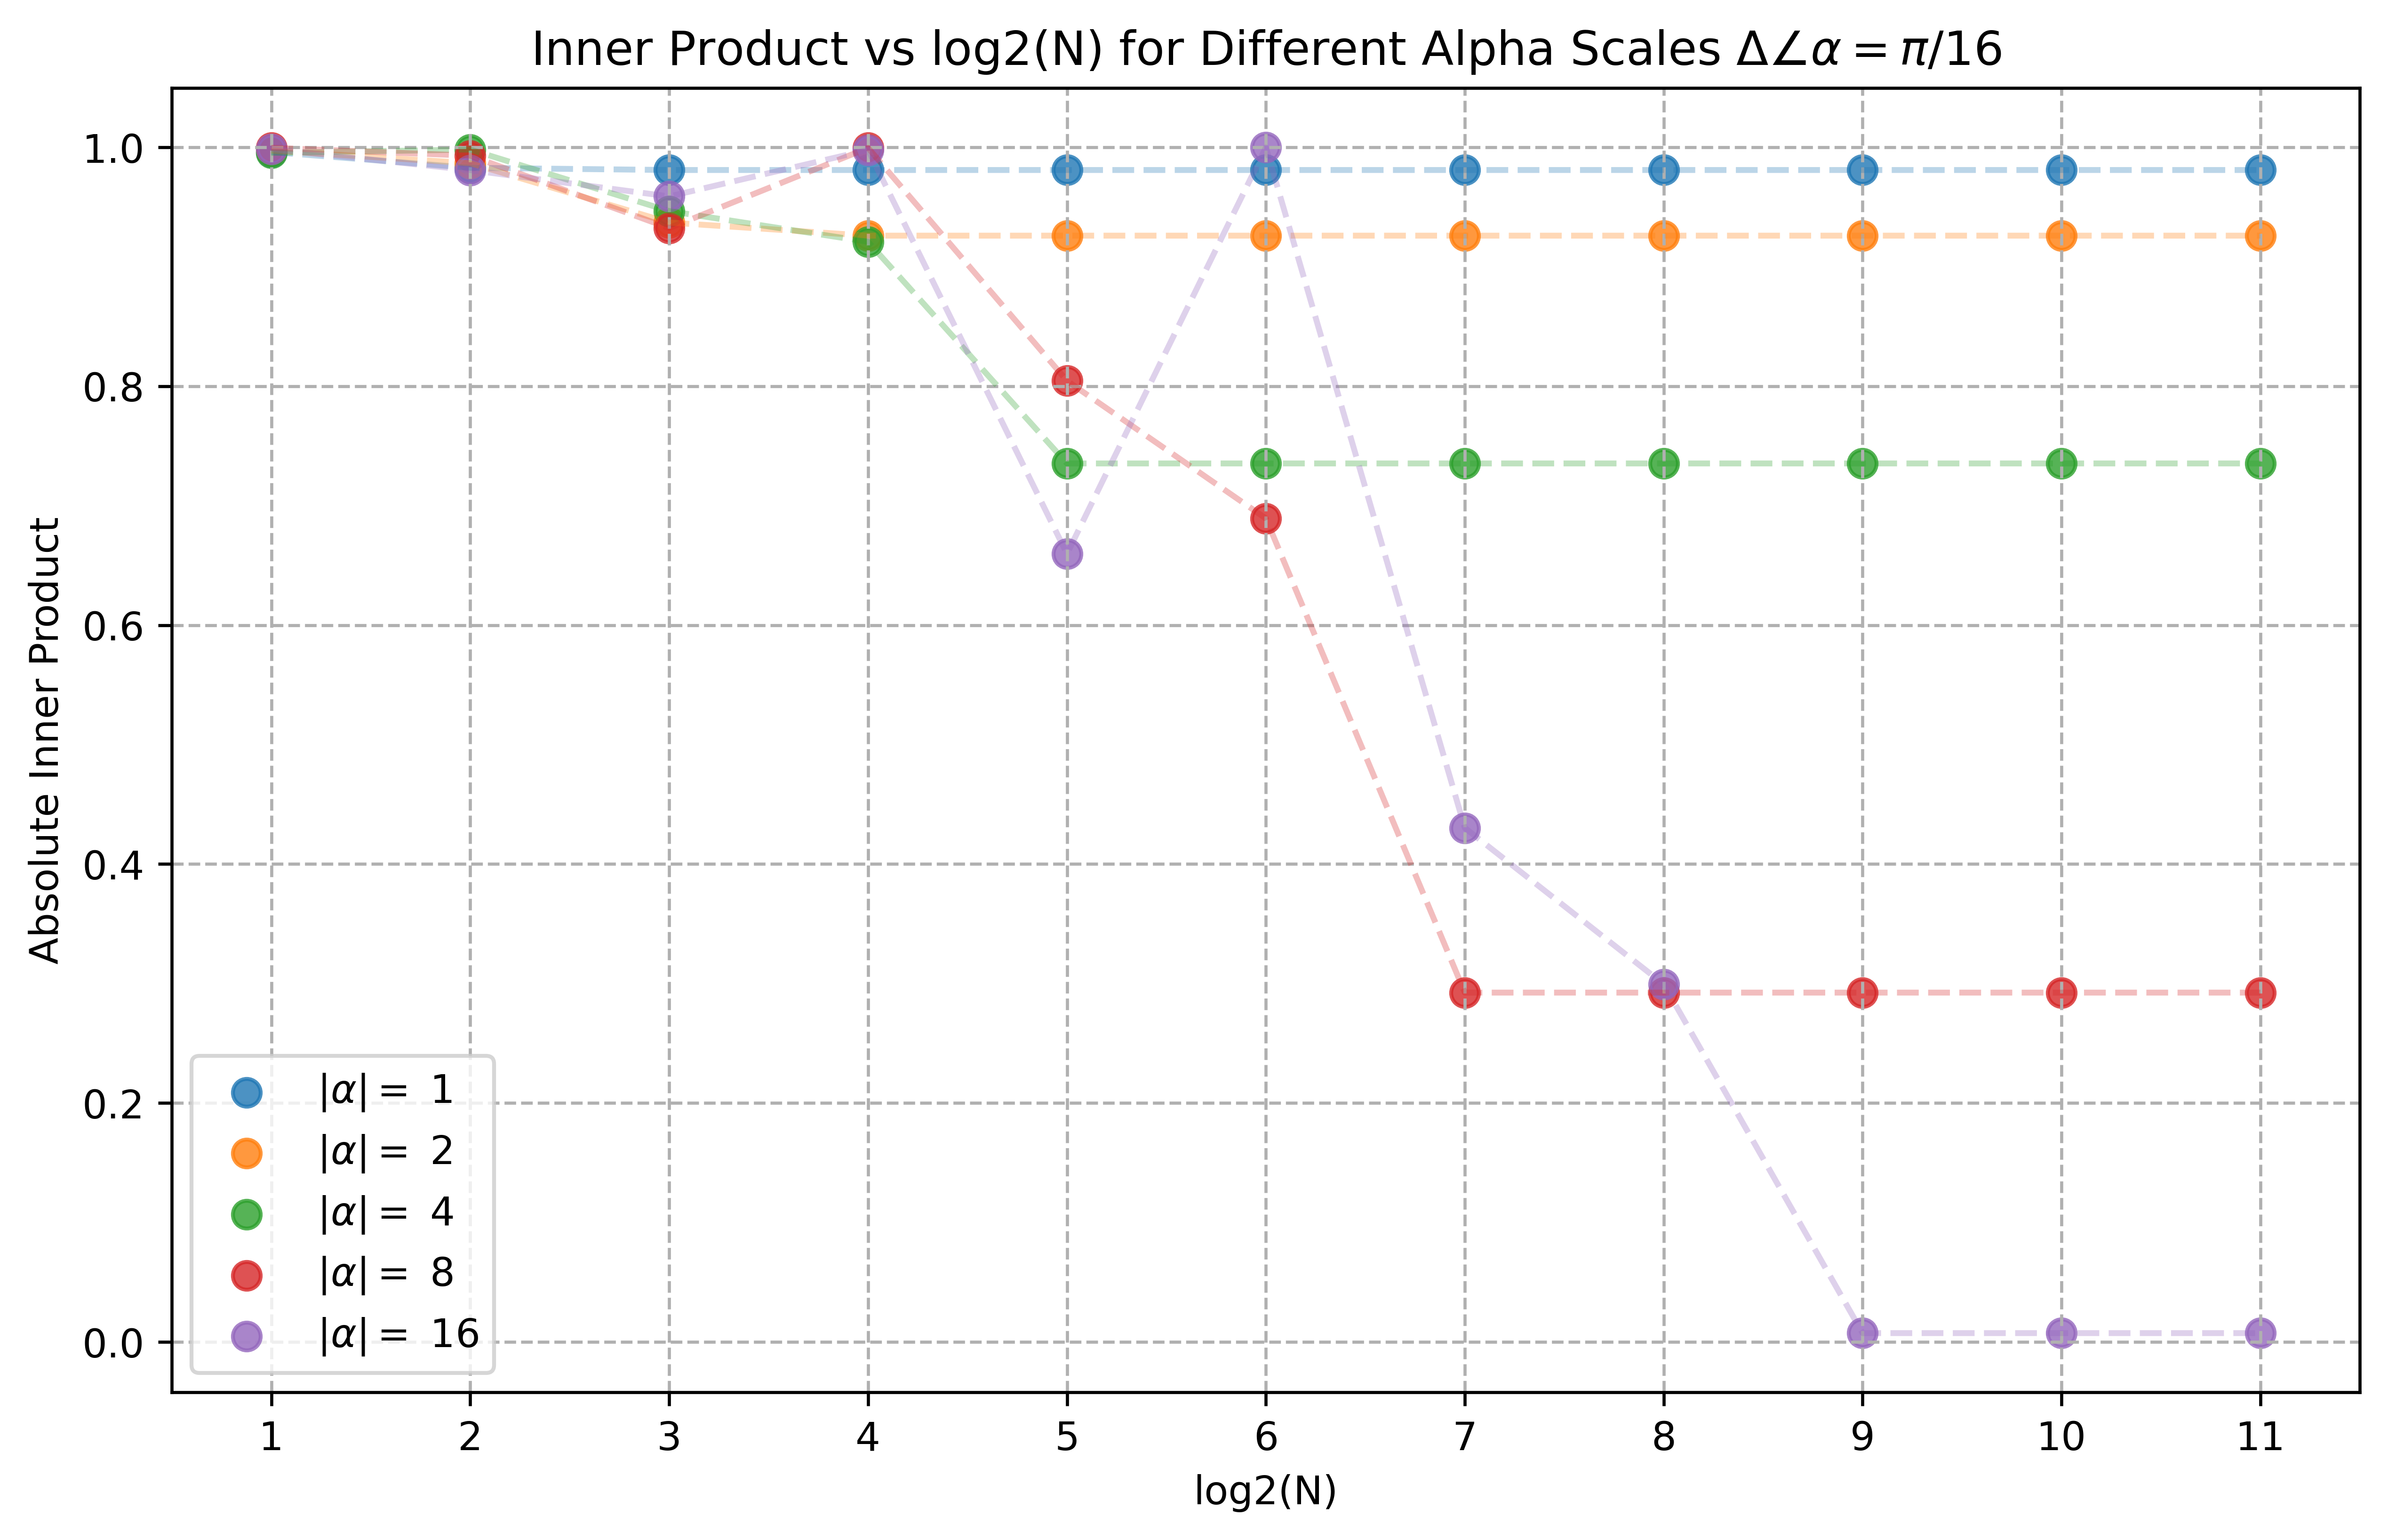

In [ ]:
# Plotting
log2_N = list(range(1, 12))
plt.figure(figsize=(10, 6), dpi=600)
for j in range(len(alpha_scales)):
    y_values = [results[i][j] for i in range(len(log2_N))]
    plt.scatter(log2_N, y_values, label=rf'$|\alpha|=$ {alpha_scales[j]}', s=50, alpha=0.8)
    plt.plot(log2_N, y_values, linestyle='--', alpha=0.3)  # Optional dashed line for clarity
plt.xlabel('log2(N)')
plt.ylabel('Absolute Inner Product')
plt.title(r'Inner Product vs log2(N) for Different Alpha Scales $\Delta{\angle{\alpha}} = \pi/16$')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.xticks(log2_N)  # Ensure x-axis ticks are at integer values of log2(N)
plt.show()

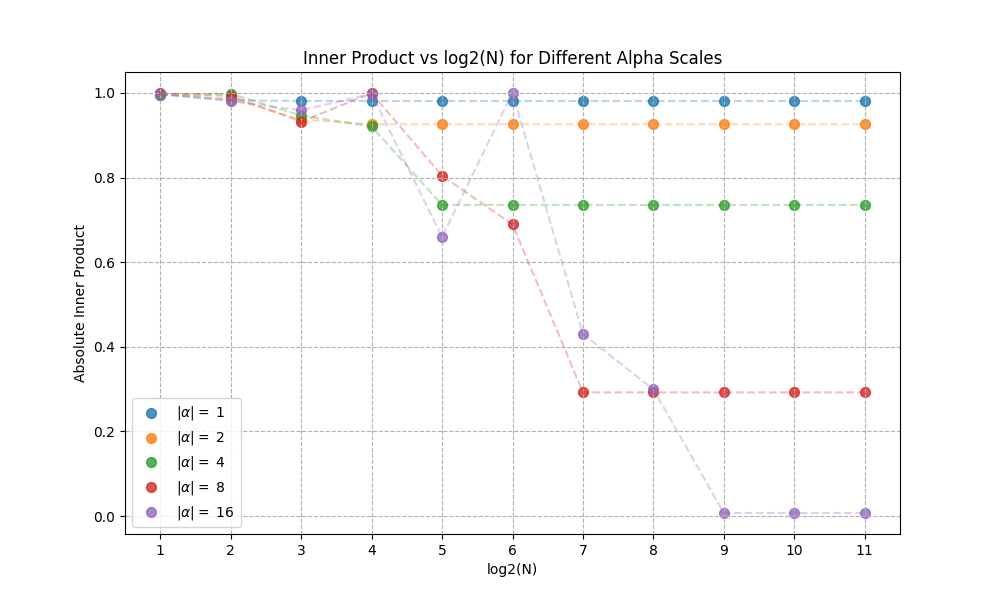

In [ ]:
%matplotlib widget
# Plotting
log2_N = list(range(1, 12))
plt.figure(figsize=(10, 6))
lines = []  # Store plot objects for toggling
for j in range(len(alpha_scales)):
    y_values = [results[i][j] for i in range(len(log2_N))]
    scatter = plt.scatter(log2_N, y_values, label=rf'$|\alpha|=$ {alpha_scales[j]}', s=50, alpha=0.8)
    line, = plt.plot(log2_N, y_values, linestyle='--', alpha=0.3)
    lines.append((scatter, line))  # Store both scatter and line for each alpha scale

plt.xlabel('log2(N)')
plt.ylabel('Absolute Inner Product')
plt.title('Inner Product vs log2(N) for Different Alpha Scales')
plt.grid(True, which="both", ls="--")
plt.xticks(log2_N)

# Make legend interactive
legend = plt.legend()
for legline, plot_objs in zip(legend.get_lines(), lines):
    legline.set_picker(True)  # Enable picking on legend lines
    legline.set_pickradius(5)  # Sensitivity area for clicking

# Toggle visibility on click
def on_pick(event):
    legline = event.artist
    index = legend.get_lines().index(legline)
    scatter, line = lines[index]
    visible = not scatter.get_visible()  # Toggle visibility
    scatter.set_visible(visible)
    line.set_visible(visible)
    legline.set_alpha(1.0 if visible else 0.2)  # Dim legend when hidden
    plt.draw()

plt.connect('pick_event', on_pick)
plt.show()

In [ ]:
# for i in range(1, 12):
#     state_0 = coherent(N=2**i, alpha=alpha_arr[0] * 4).data.to_array().flatten()
#     state_1 = coherent(N=2**i, alpha=alpha_arr[1] * 4).data.to_array().flatten()
# 
#     print(np.abs(np.vdot(state_0, state_1)))

In [ ]:
# Maybe it is not that trivial after noise is involved?


In [ ]:
# Discussion with 仲凱
# Discriminate untruncated coherent states (ex. N=1024?) by solving the POVM for truncated coherent states (ex. N=32)
# Find alpha, if |alpha| is integer or in some known range


## Construct an algorithm for whole thing...